In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcYmV0aGFubnkuZGFuc2tpblxEb2N1bWVudHNcR2l0SHViXGVkdWNhdGlvbl9vdXRyZWFjaFxtaWNyb25zX3dvcmtzaG9wX3B1Z2V0X3NvdW5kXGRvY3Ncbm90ZWJvb2tz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\bethanny.danskin\\AppData\\Local\\uv\\python\\cpython-3.11-windows-x86_64-none\\Lib\\importlib\\_bootstrap.py": 1789838406.8538861, "C:\\Users\\bethanny.danskin\\AppData\\Local\\uv\\python\\cpython-3.11-windows-x86_64-none\\Lib\\importlib\\_bootstrap_external.py": 1789838406.854897, "C:\\Users\\bethanny.danskin\\AppData\\Local\\uv\\python\\cpython-3.11-windows-x86_64-none\\Lib\\zipimport.py": 1789838408.8541622, "C:\\Users\\bethanny.danskin\\AppData\\Local\\uv\\python\\cpython-3.11-windows-x86_64-none\\Lib\\codecs.py": 1789838406.26, "C:\\Users\\bethanny.danskin\\AppData\\Local\\uv\\python\\cpython-3.11-windows-x86_64-none\\Lib\\encodings\\aliases.py": 1789838406.4581091, "C:\\Users\\bethanny.danskin\\AppData\\Local\\uv\\python\\cpython-3.11-windows-x86_64-none\\Lib\\encodings\\__init__.py": 1789838406.449744, "C:\\Users\\bethanny.danskin\\AppData\\Local\\uv\\python\\cpython-3.11-windows-x86_64-none\\Lib\\encodings\\utf_8.py": 1789838406.630591, "C:\\Users\\bethanny.danski

In [2]:
from os.path import join as pjoin
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#| eval: false
# Colab only — install packages. Skipped when rendering the website.
!uv pip install caveclient cloud-volume ossify


In [4]:
#| eval: false
from caveclient import CAVEclient

# In Colab, store your token once (see Setup & FAQ), then load it:
from google.colab import userdata
client = CAVEclient("minnie65_public", auth_token=userdata.get("CAVE_TOKEN"))

# Or paste a token directly:
# client = CAVEclient("minnie65_public", auth_token="YOUR_TOKEN")


In [5]:
#| echo: false
# Local site render only: reuse a CAVE token already saved on this machine.
# In Colab this is skipped because `client` is already defined above.
try:
    client
except NameError:
    from caveclient import CAVEclient
    client = CAVEclient("minnie65_public")


In [6]:
import ossify

# Load basic cell (skeleton + L2 graph)
root_id = 864691135774053371 # known Layer 2/3 cell at v1718

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")
print(f"Graph: {cell.graph.n_vertices} L2 vertices")

ImportError: Could not import cloudvolume. Make sure it is installed. See https://pypi.org/project/cloud-volume for more info.

NameError: name 'cell' is not defined

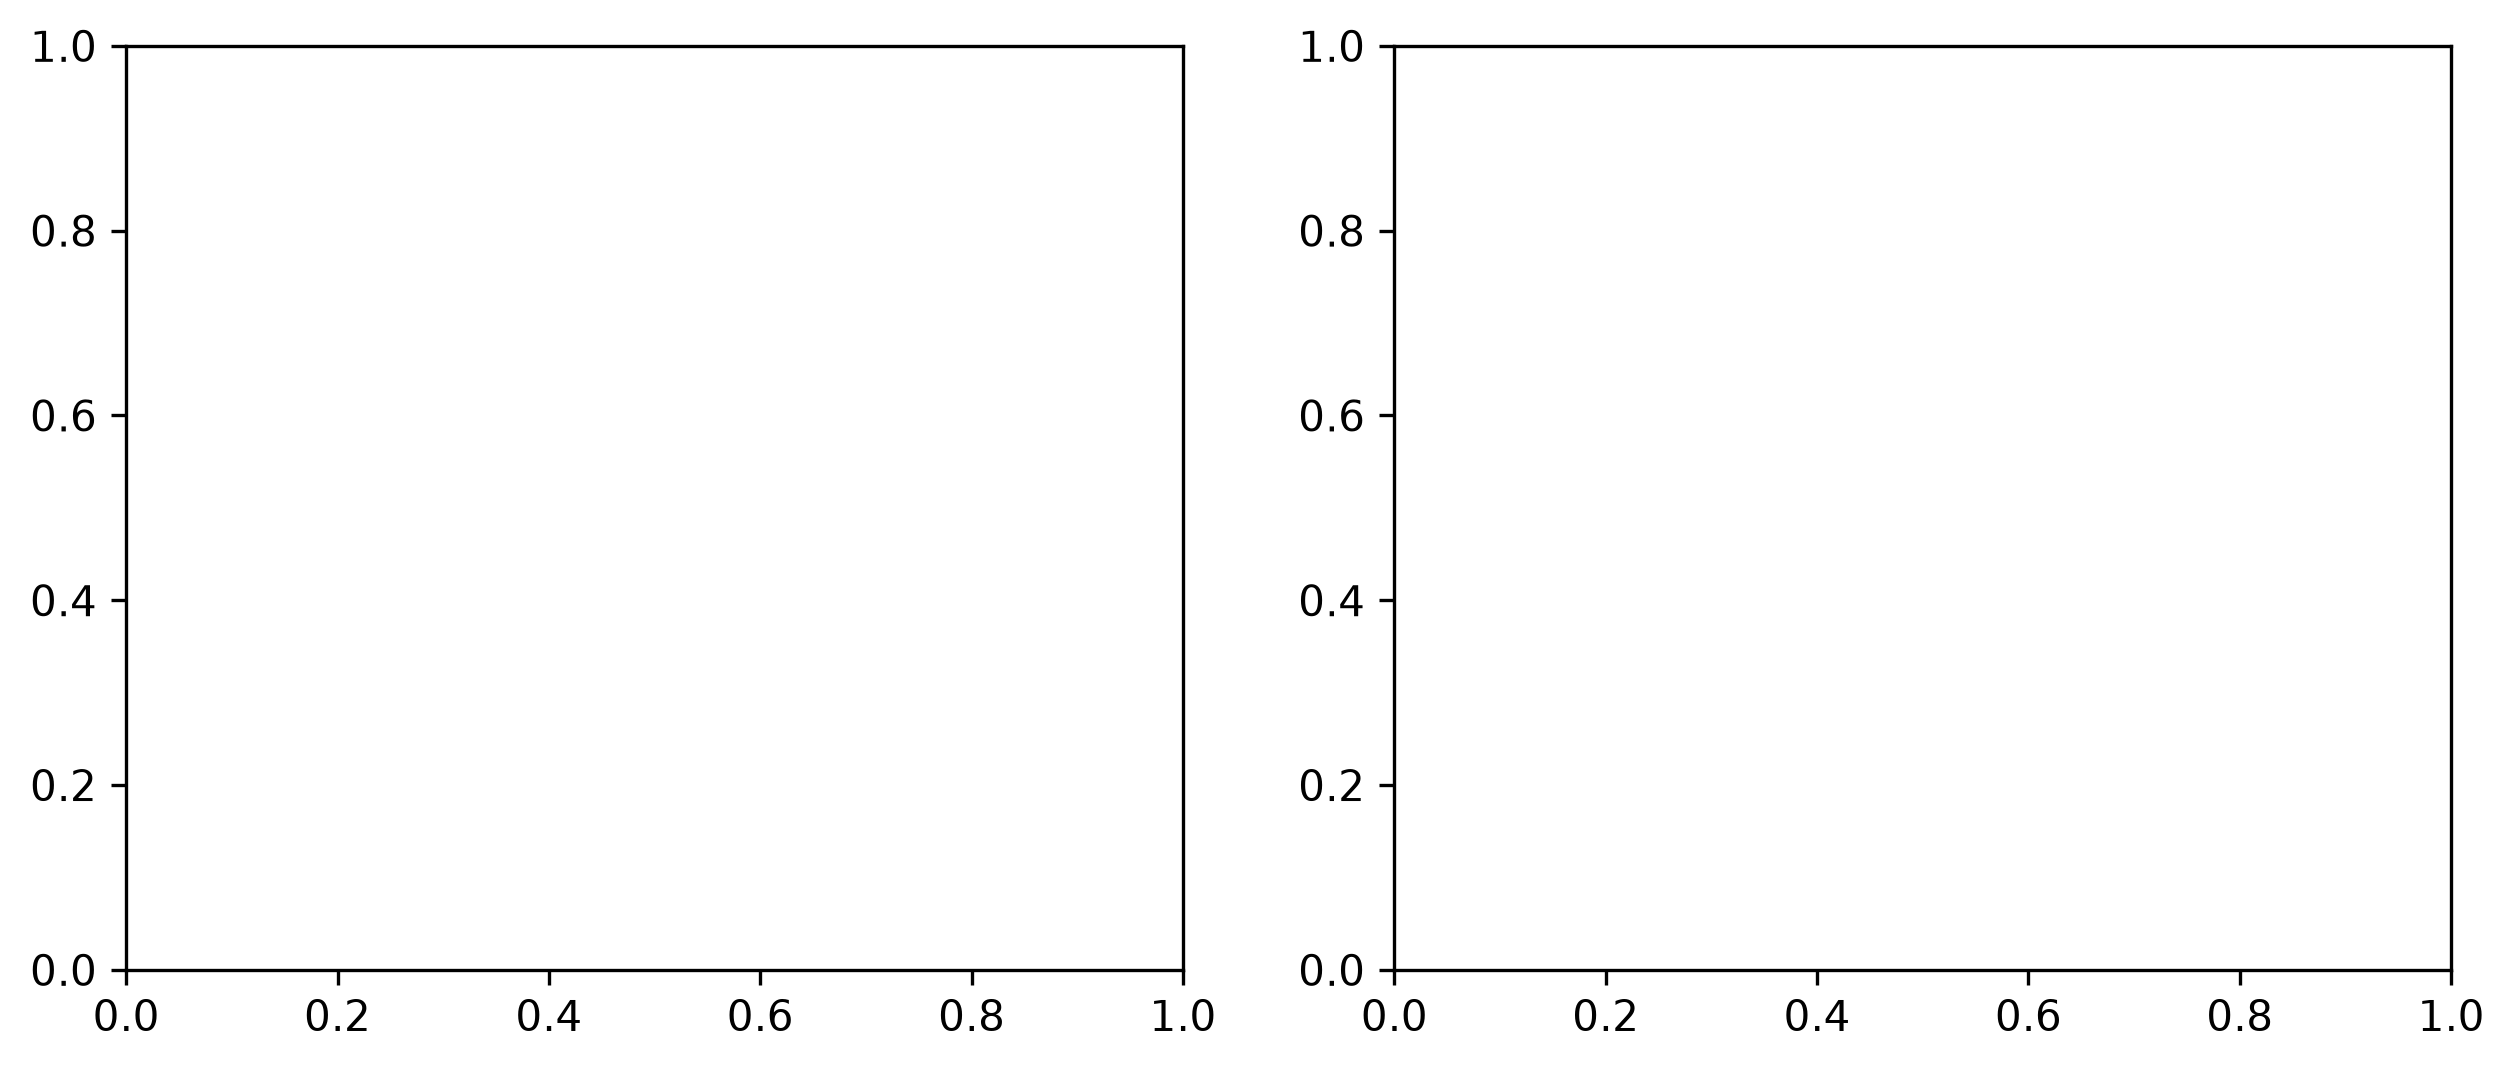

In [7]:
# @title Figure 1: Skeleton representation in 2D

# Plot different 2D projections
projections = ["xy", "zy"] # , 'xz']
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i, proj in enumerate(projections):
    ossify.plot.plot_morphology_2d(
        cell,
        projection=proj,
        color="compartment",
        palette={ossify.SWC_SOMA: 'navy', ossify.SWC_AXON: 'tomato', ossify.SWC_DENDRITE: 'black'},  # SWC compartment codes (soma/axon/dendrite)
        linewidth="radius",            # line thickness follows neurite radius
        linewidth_norm=(100, 1000),    # radii (nm) mapped to the widths below
        widths=(0.25, 2),
        ax=axes[i]
    )
    axes[i].set_title(f"Projection: {proj}")
    axes[i].set_ylabel(f"(nm)")
    axes[i].set_xlabel(f"(nm)")
    axes[i].set_aspect("equal")

axes[0].set(xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
axes[1].set(xlabel='Z, anterior-posterior (nm)')
sns.despine()
plt.tight_layout()
plt.show()

In [8]:
# Load skeleton with synaptic features
root_id = 864691135774053371 # known Layer 2/3 cell at v1718

cell = ossify.load_cell_from_client(
    root_id=root_id,
    client=client,
    synapses=True, # optional argument to load synapses with skeleton
    include_partner_root_id=True, # optional argument to load partner root ids with synapses
)

print(f"Loaded cell {cell.name}")
print(f"Skeleton: {cell.skeleton.n_vertices} vertices")
print(f"Graph: {cell.graph.n_vertices} L2 vertices")

# All annotations in the cell
cell.annotations.describe()

ImportError: Could not import cloudvolume. Make sure it is installed. See https://pypi.org/project/cloud-volume for more info.

In [9]:
# Synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

# return the available columns to line
pre_syn_df.columns

NameError: name 'cell' is not defined

NameError: name 'cell' is not defined

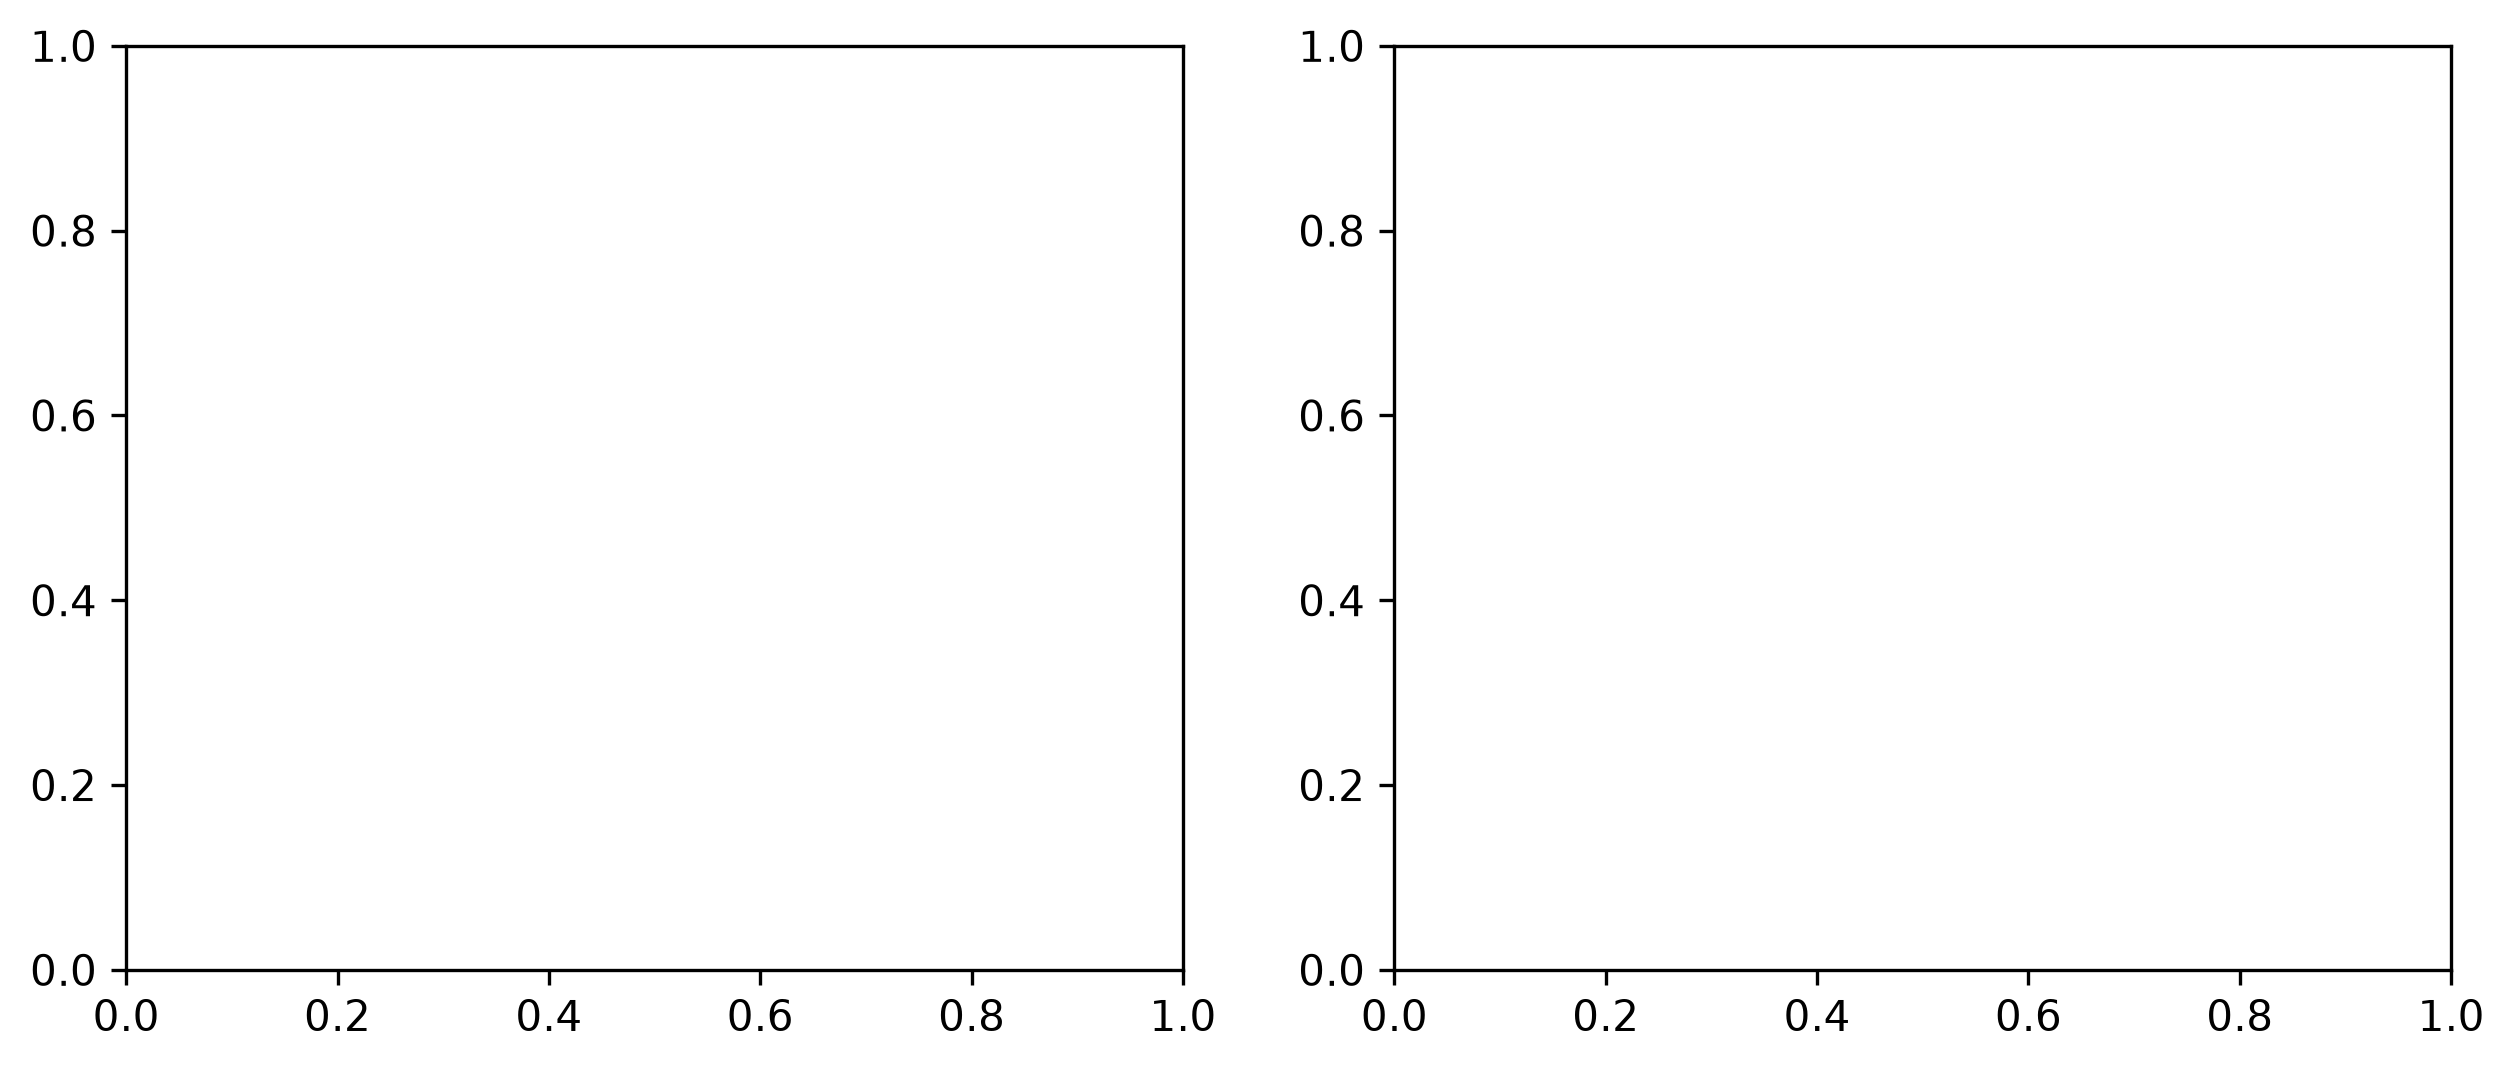

In [10]:
# @title Figure 2: Skeleton with synaptic inputs and outputs

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={ossify.SWC_SOMA: 'navy', ossify.SWC_AXON: 'tomato', ossify.SWC_DENDRITE: 'black'},  # SWC compartment codes (soma/axon/dendrite)
                                   linewidth="radius",            # line thickness follows neurite radius
                                   linewidth_norm=(100, 1000),    # radii (nm) mapped to the widths below
                                   widths=(0.25, 2),
                                   ax=ax[i])

# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=3, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100)
ax[0].text(.65,.75,f'{len(pre_syn_df)} total', color='darkviolet',  transform = ax[0].transAxes)


# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=3, color="teal", ax=ax[1], edgecolor=None, zorder=100)
ax[1].text(.65,.75,f'{len(post_syn_df)} total', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')

sns.despine()
plt.show()

In [11]:
pre_syn_df.head()[['pre_pt_root_id','post_pt_root_id','size','ctr_pt_position_x','ctr_pt_position_y','ctr_pt_position_z']]

NameError: name 'pre_syn_df' is not defined

In [12]:
# get count of synapses between presynaptic and postsynaptic partners
output_connectivity = (pre_syn_df.groupby(['pre_pt_root_id', 'post_pt_root_id'])
 .count()[['size']]
 .rename(columns={'size': 'syn_count'})
 .sort_values( by='syn_count', ascending=False,)
)

output_connectivity
# Note that the 'size' part here is just a way to quickly extract one column. This could be any of the remaining column names.

NameError: name 'pre_syn_df' is not defined

In [13]:
# get count of synapses between presynaptic partners
input_connectivity = ...


In [14]:
# get the root_ids that have a "known" soma
soma_df= client.materialize.views.nucleus_detection_lookup_v1().query(
    select_columns = ['id','pt_root_id']
)

# Filter output synapses to known postsynaptic cells
pre_syn_to_known_df = pre_syn_df.loc[pre_syn_df.post_pt_root_id.isin(soma_df.pt_root_id)]

# Filter input synapses from known postsynaptic cells
post_syn_from_known_df = post_syn_df.loc[post_syn_df.pre_pt_root_id.isin(soma_df.pt_root_id)]

NameError: name 'pre_syn_df' is not defined

NameError: name 'cell' is not defined

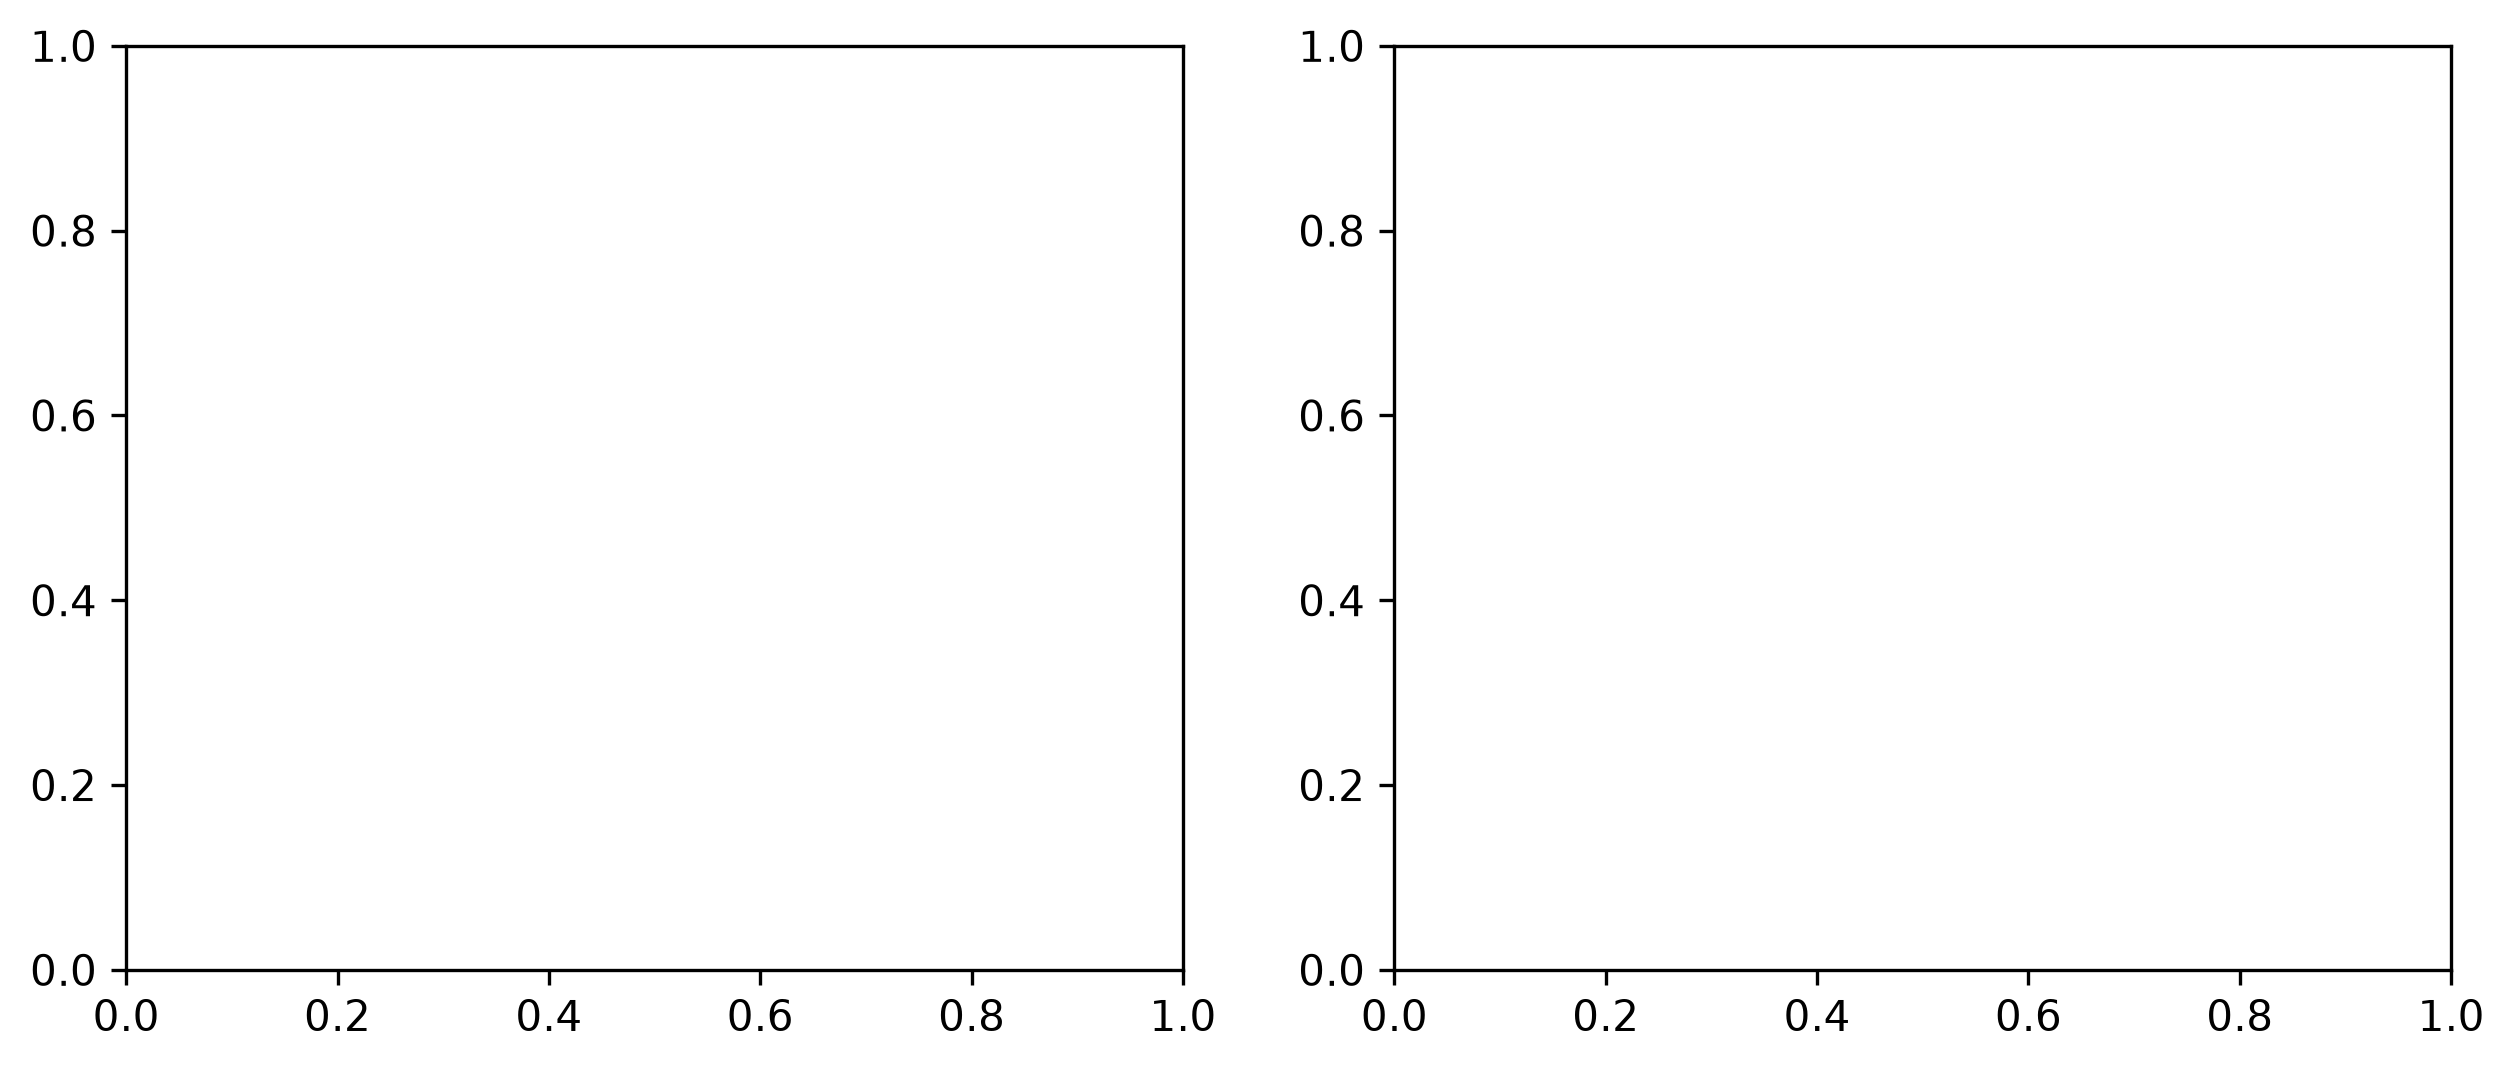

In [15]:
# @title Figure 3: Skeleton with inputs and outputs, filtered by 'known' connections

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

point_size = 3

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={ossify.SWC_SOMA: 'navy', ossify.SWC_AXON: 'tomato', ossify.SWC_DENDRITE: 'black'},  # SWC compartment codes (soma/axon/dendrite)
                                   linewidth="radius",            # line thickness follows neurite radius
                                   linewidth_norm=(100, 1000),    # radii (nm) mapped to the widths below
                                   widths=(0.25, 2),
                                   ax=ax[i])
# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="lightgrey", ax=ax[0], edgecolor=None, zorder=100)
sns.scatterplot(data=pre_syn_to_known_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="darkviolet", ax=ax[0], edgecolor=None, zorder=100, alpha=0.5)
ax[0].text(.6,.75,f'{len(pre_syn_df)} total', color='lightgrey',  transform = ax[0].transAxes)
ax[0].text(.6,.7,f'{len(pre_syn_to_known_df)} to known', color='darkviolet',  transform = ax[0].transAxes)

# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="lightgrey", ax=ax[1], edgecolor=None, zorder=100)
sns.scatterplot(data=post_syn_from_known_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, color="teal", ax=ax[1], edgecolor=None, zorder=100, alpha=0.5)
ax[1].text(.6,.75,f'{len(post_syn_df)} total', color='lightgrey',  transform = ax[1].transAxes)
ax[1].text(.6,.7,f'{len(post_syn_from_known_df)} from known', color='teal',  transform = ax[1].transAxes)

ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.show()

In [16]:
materialization_version = 1718 # Current public as of March 2026
data_url = "https://github.com/AllenInstitute/connectomics_at_cosyne/raw/refs/heads/main/docs/resources/data"

# Load the curated cell types table
cell_types_df = pd.read_csv(f"{data_url}/v{materialization_version}_cell_info.csv")

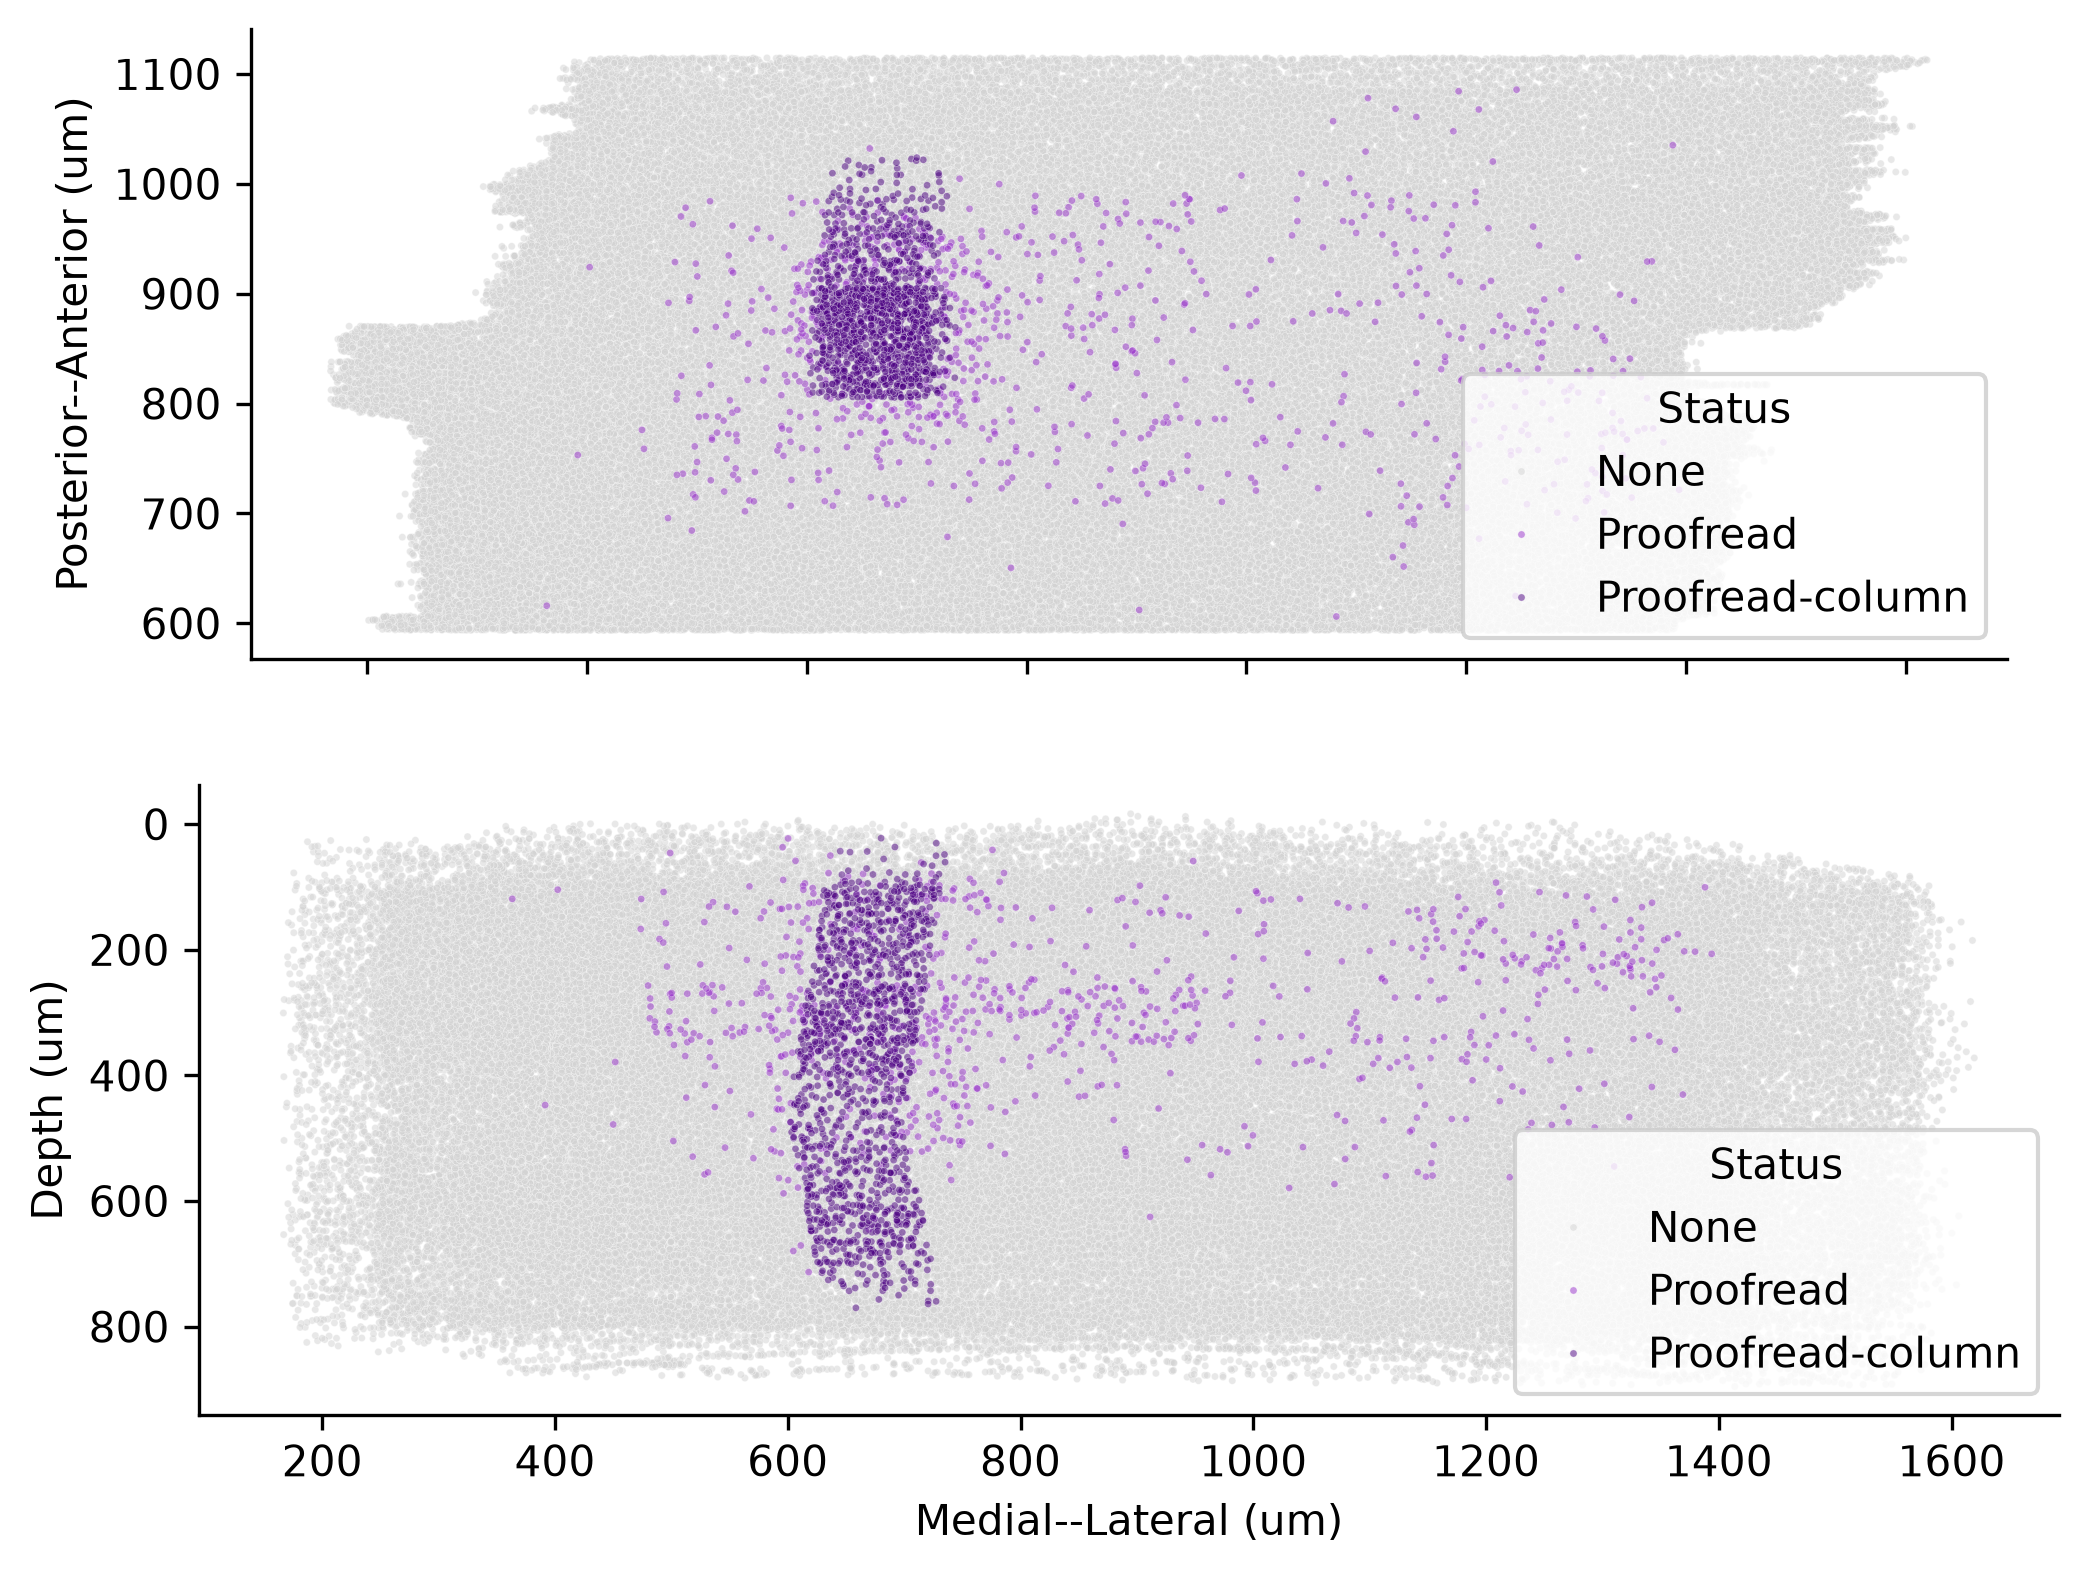

In [17]:
# @title Figure 5: Spatial position of neurons in MICrONS

fig, ax = plt.subplots(2,1, figsize=(8, 6),dpi=150, sharex=True)

# Added a labeled column for ease of plotting
cell_types_df['Status'] = 'None'
cell_types_df.loc[cell_types_df.status_axon, 'Status'] = 'Proofread'
cell_types_df.loc[cell_types_df.is_column, 'Status'] = 'Proofread-column'
cell_types_df = cell_types_df.sort_values('Status')

# Plot xz-view (top down)
sns.scatterplot(cell_types_df,
                x='pt_position_x_tform',
                y='pt_position_z_tform',
                hue='Status',
                hue_order = ['None', 'Proofread', 'Proofread-column'],
                palette={'Proofread-column': 'indigo', 'Proofread': 'darkorchid', 'None': 'lightgrey'},
                s=3,
                alpha=0.5,
                ax=ax[0]
               )
# Plot xy-view (coronal)
sns.scatterplot(cell_types_df,
                x='pt_position_x_tform',
                y='pt_position_y_tform',
                hue='Status',
                hue_order = ['None', 'Proofread', 'Proofread-column'],
                palette={'Proofread-column': 'indigo', 'Proofread': 'darkorchid', 'None': 'lightgrey'},
                s=3,
                alpha=0.5,
                ax=ax[1]
               )

sns.despine()
ax[1].invert_yaxis()
ax[0].set(xlabel='Medial--Lateral (um)', ylabel='Posterior--Anterior (um)')
ax[1].set(xlabel='Medial--Lateral (um)', ylabel='Depth (um)')
ax[0].set_aspect("equal")

In [18]:
column_synapses = pd.read_feather(f"{data_url}/v{materialization_version}_v1_column_synapses.feather")
column_synapses.shape

(146711, 6)

In [19]:
# matrix of synapse counts
syn_mat_binary = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: (np.sum(x) > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat_binary = syn_mat_binary.reindex(columns=np.array(syn_mat_binary.index)).astype(float)

row_indices, column_indices = np.nonzero(syn_mat_binary)

Number of edges: 78928
Number of possible edges: 1836025
Fraction of possible edges: 0.0430


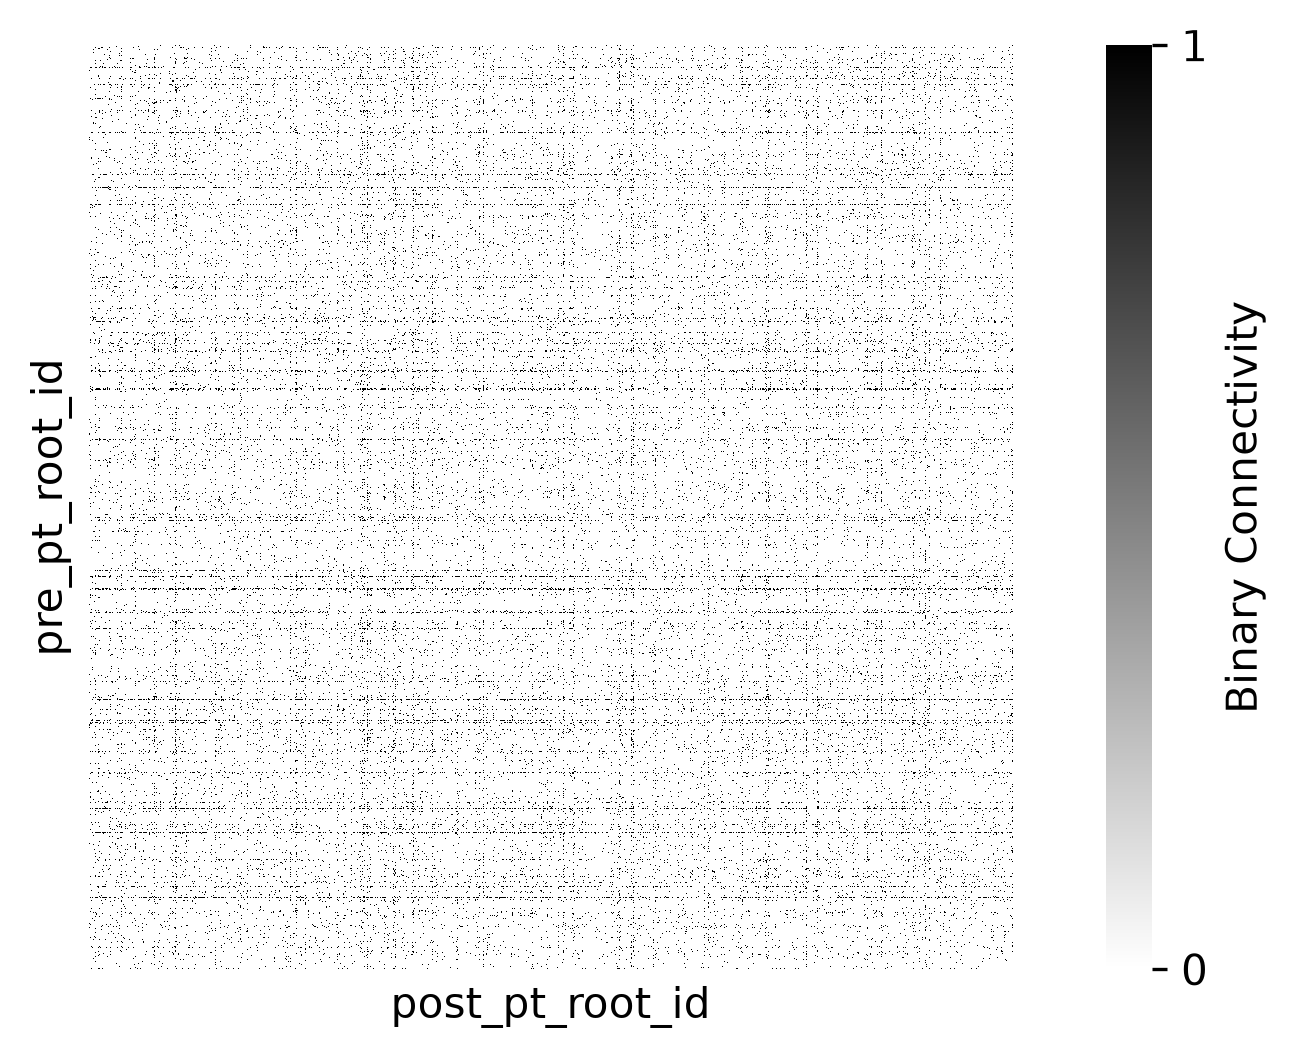

In [20]:
# @title Figure 6: Binary connectivity matrix (column-to-column)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.heatmap(syn_mat_binary, cmap="gray_r", xticklabels=[], yticklabels=[],
            ax=ax, square=True,
            cbar_kws={"label": "Binary Connectivity", "ticks": [0, 1]})


n_edges = len(row_indices)
n_possible_edges = syn_mat_binary.shape[0] * syn_mat_binary.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

In [21]:
cell_types_df.value_counts(['cell_type']).sort_index()

cell_type
23P          19650
4P           14712
5P-ET         2149
5P-IT         7890
5P-NP          932
6P-CT         6770
6P-IT        11651
BC            3354
BPC           1494
MC            2469
NGC            588
OPC           1422
astrocyte     6898
microglia     2358
oligo         6901
pericyte       374
Name: count, dtype: int64

In [22]:
nucleus_df = client.materialize.query_table('nucleus_detection_v0',
                                            desired_resolution=[1000, 1000, 1000], # returned in um
                                            split_positions=True,
                                            select_columns=['id','pt_root_id','volume','pt_position']
                                           )
nucleus_df.sample(5)

,id,pt_supervoxel_id,pt_root_id,volume,pt_position_x,pt_position_y,pt_position_z
61191,519788,105492712249328637,864691136662387678,64.266899,1185,539,723
27426,662723,114997922223421267,864691135835013319,47.12661,1461,701,940
81899,105837,0,0,105.568665,446,429,1072
23637,305273,89671359139413716,864691134989003898,284.999023,724,886,958
110864,590237,111765082354144385,864691135740219755,244.482208,1367,824,680


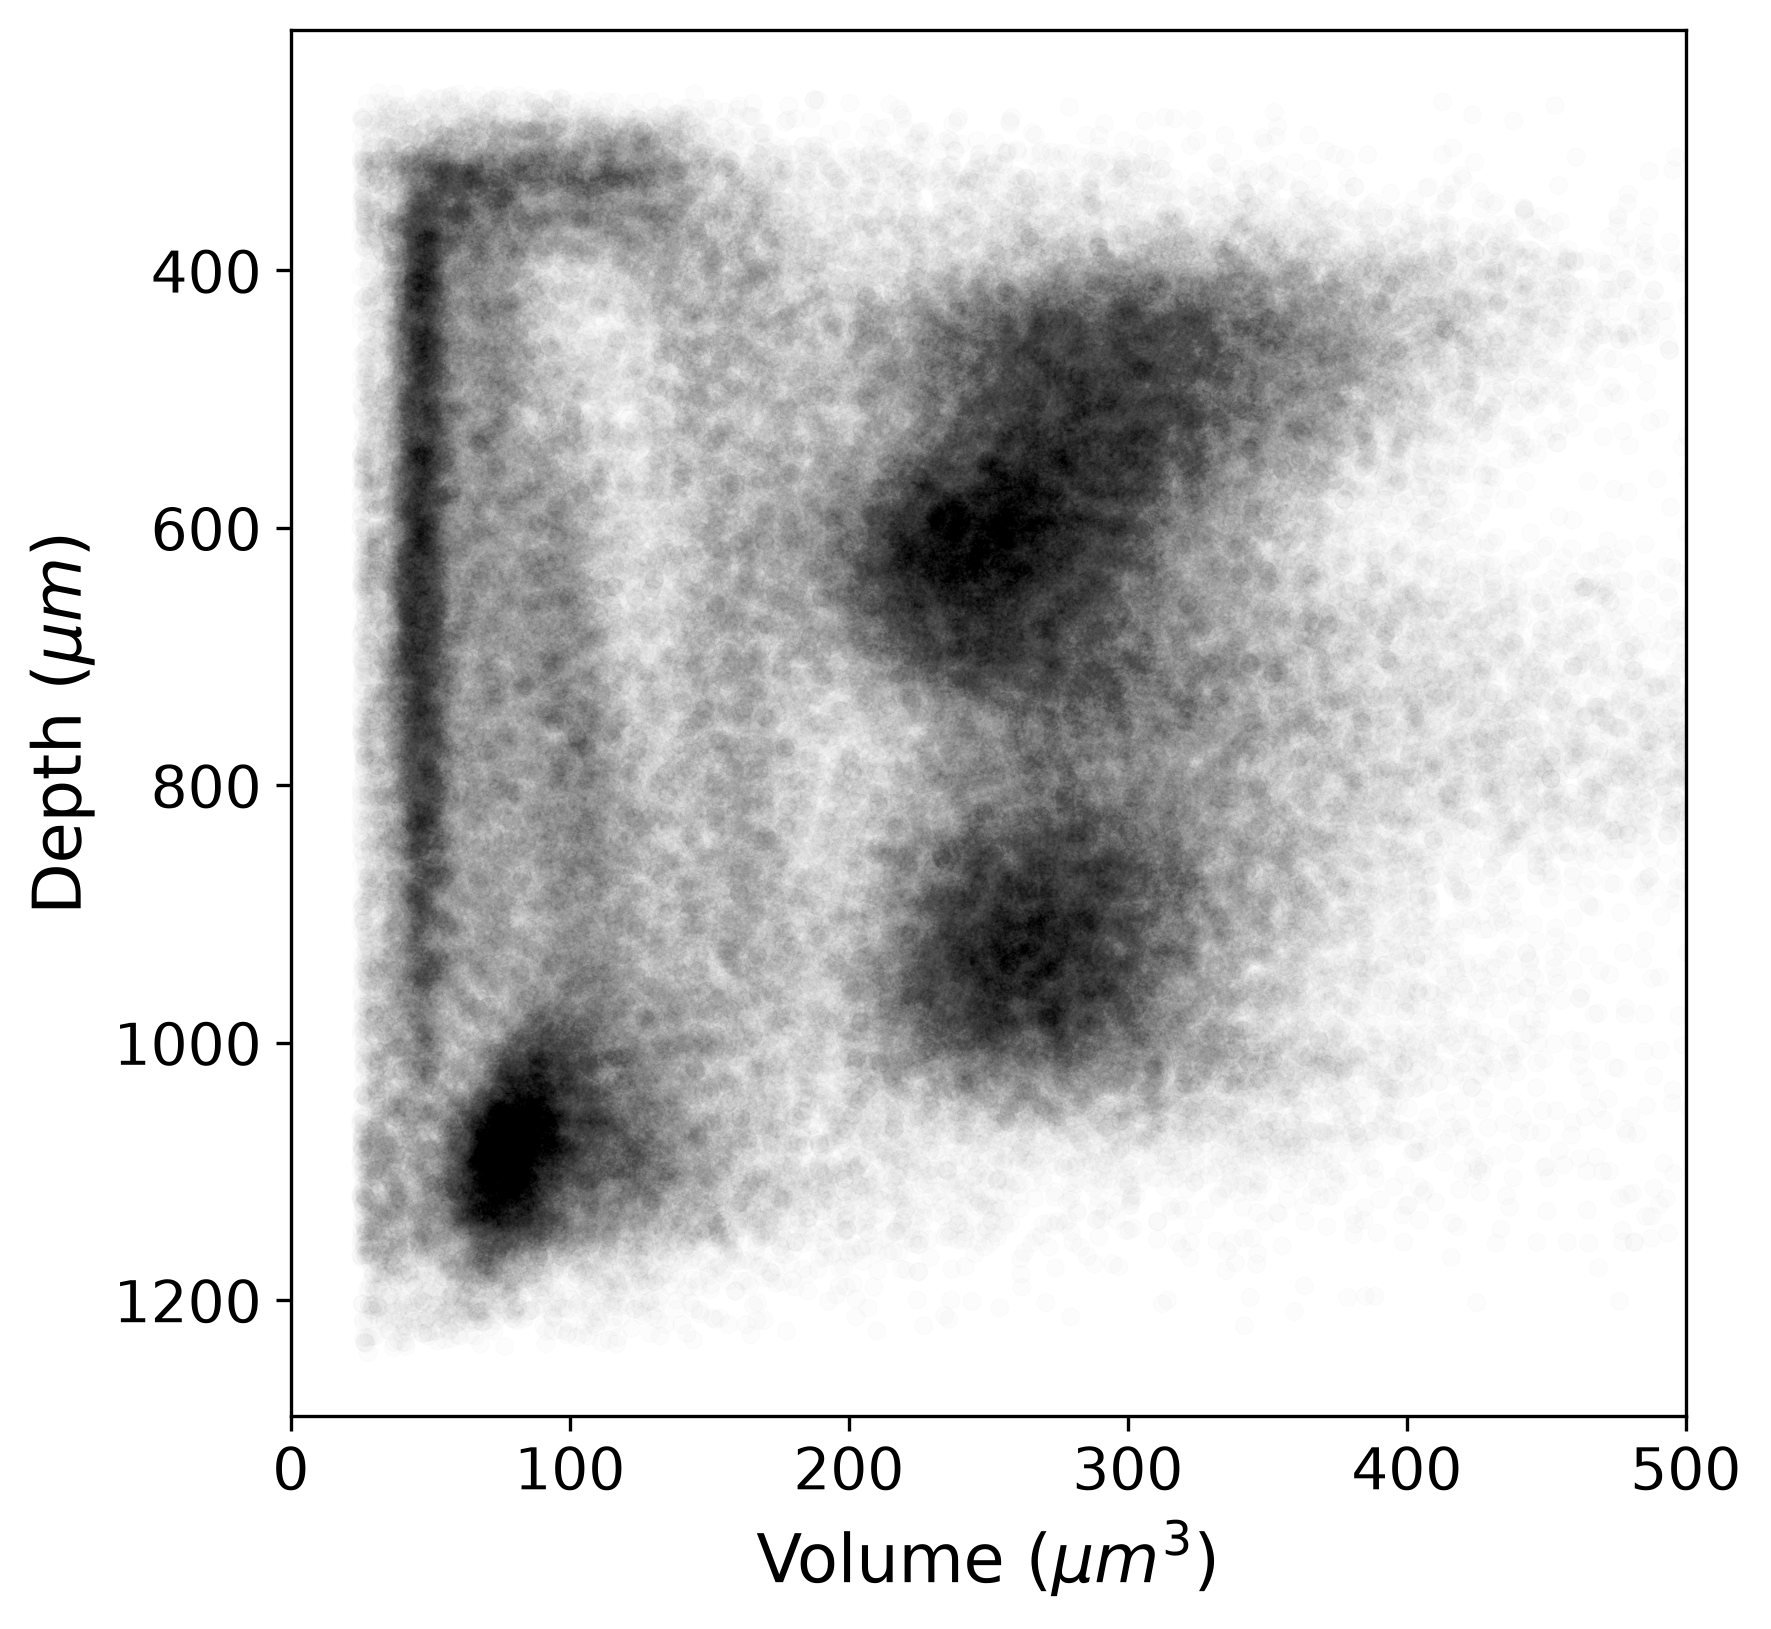

In [23]:
# @title Figure 7: Spatial Organization of Cell Nuclei in the tissue

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)
sns.scatterplot(data=nucleus_df, x="volume", y="pt_position_y", size=1, edgecolor=None, alpha=.01, color="k", ax=ax, legend=False)
ax.invert_yaxis()
ax.set_xlabel("Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel("Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 500)
plt.show()

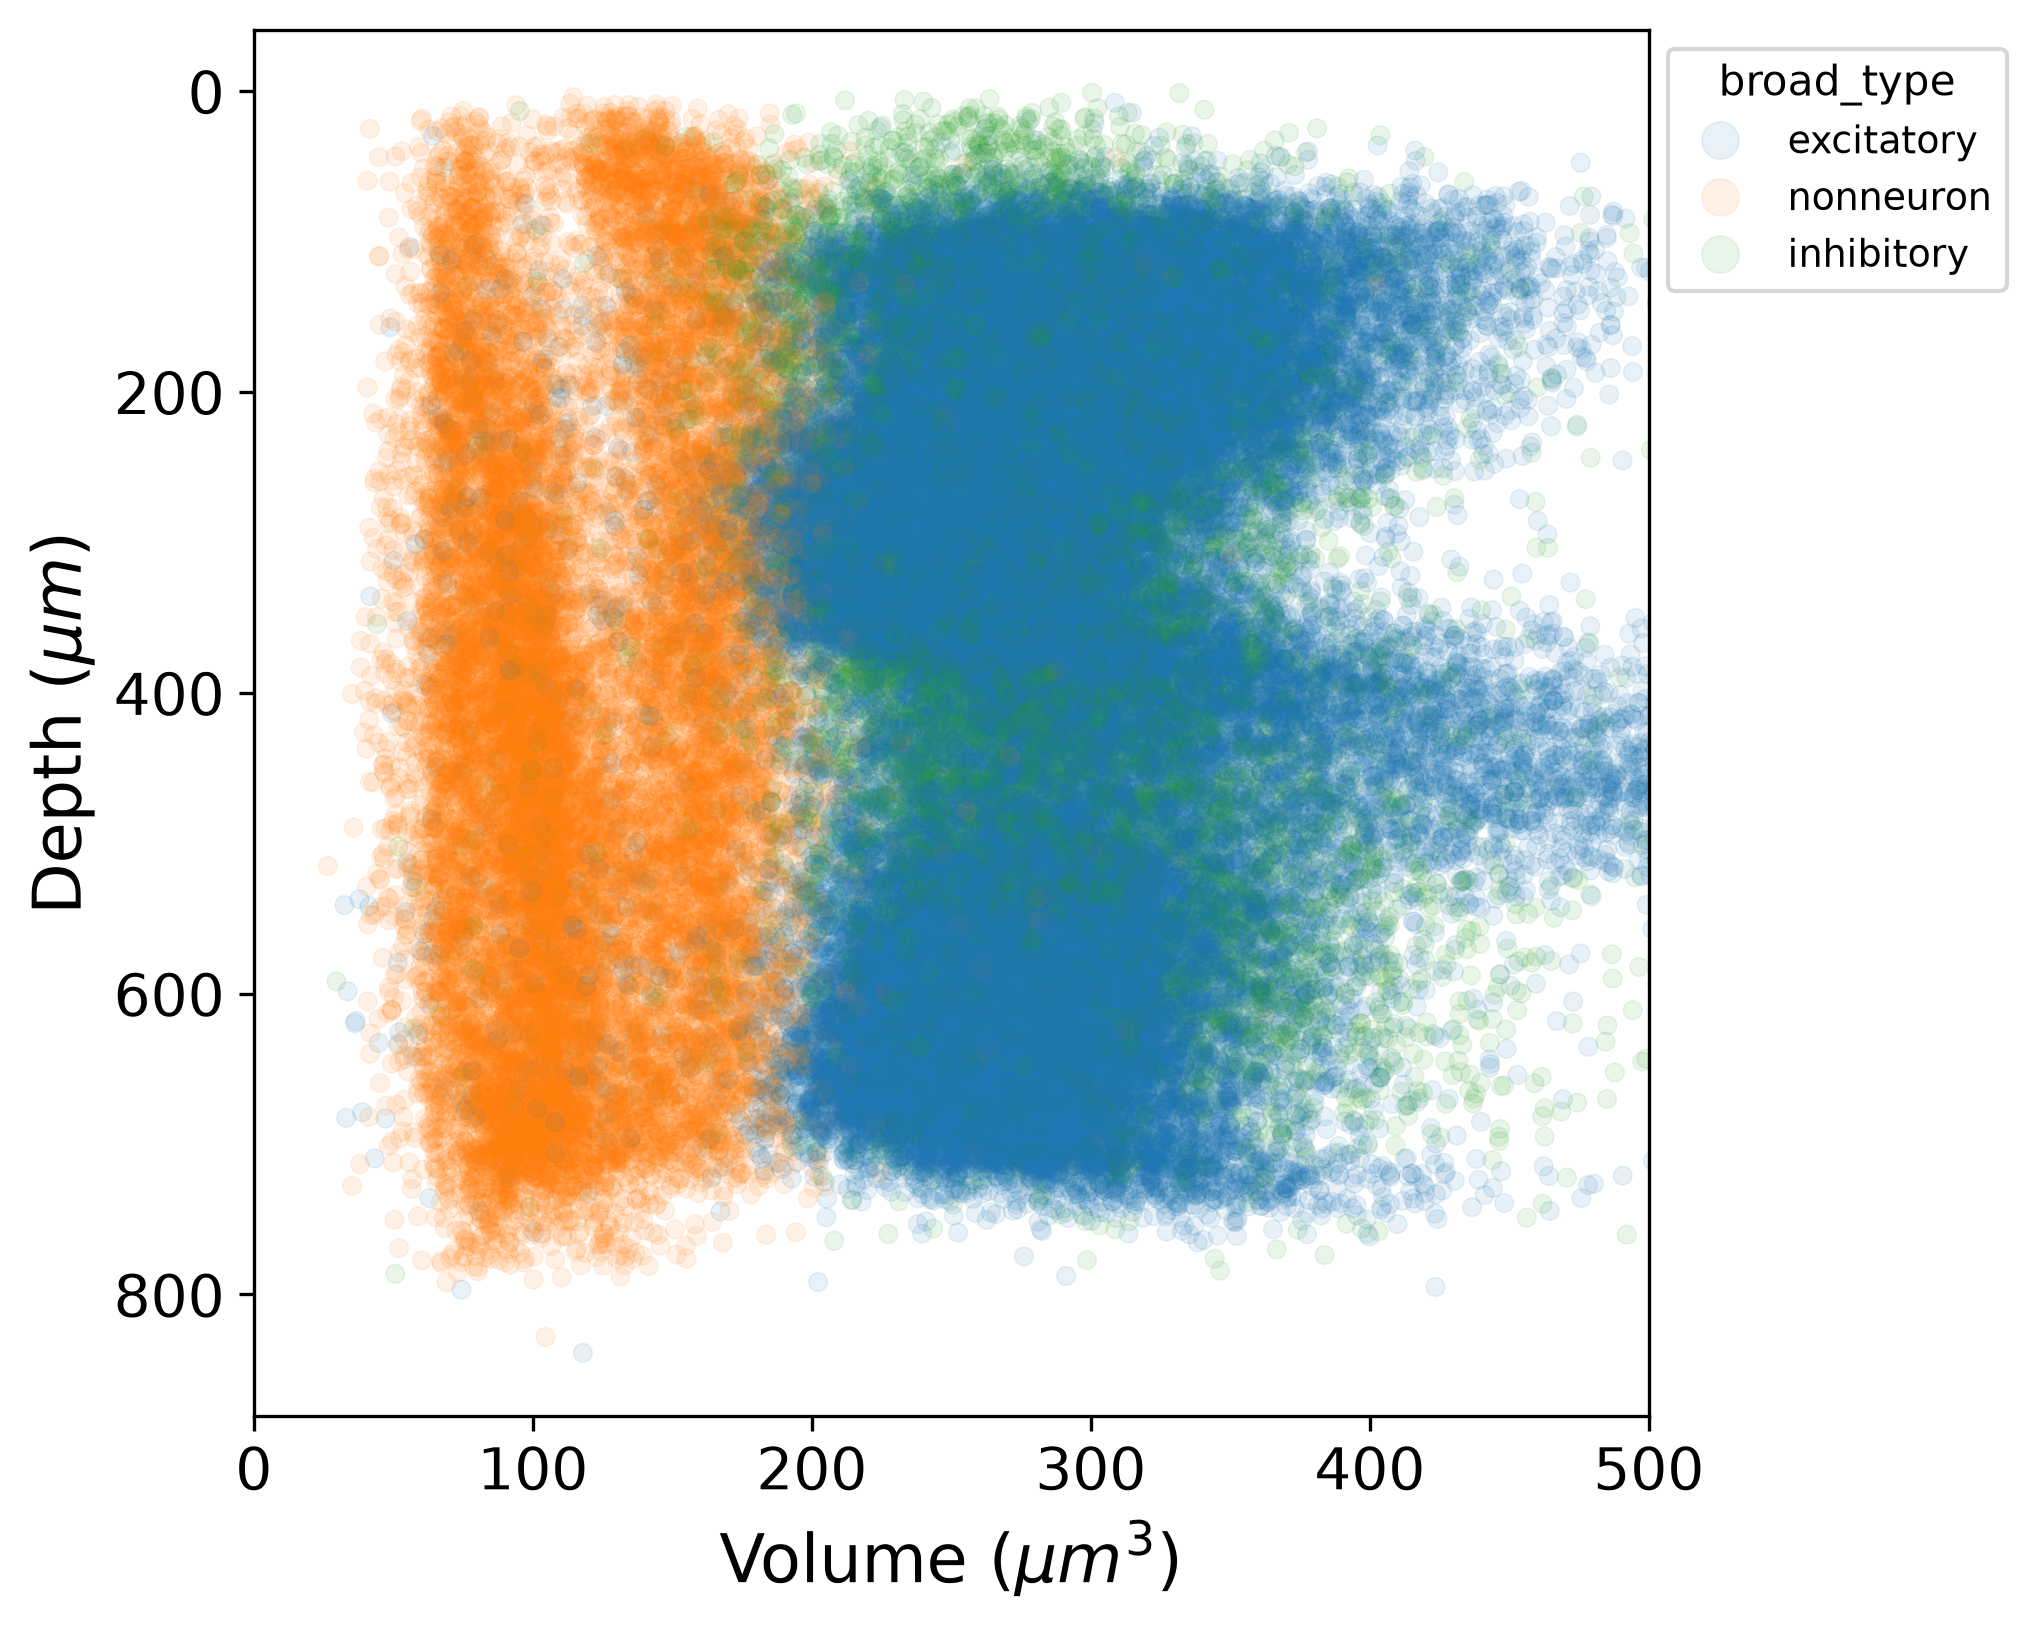

In [24]:
# @title Figure 7b: Spatial Organization of Cell Types (Excitatory, Inhibitory, non-neuronal) in the tissue

# merge cell nucleus size to cell type
if 'volume' not in cell_types_df.columns:
    cell_types_df = cell_types_df.merge(nucleus_df[['id','volume']])

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)
sns.scatterplot(data=cell_types_df.query("broad_type!='unknown'"),
                x="volume", y="pt_position_y_tform",
                s=20, edgecolor=None, alpha=.1, color="k", ax=ax,
                legend=True, hue="broad_type", )
ax.invert_yaxis()
ax.set_xlabel("Volume ($\mu m^3$)", fontsize=16)
ax.set_ylabel("Depth ($\mu m$)", fontsize=16)
ax.set_xlim(0, 500)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), fontsize=9, markerscale=2)
plt.show()

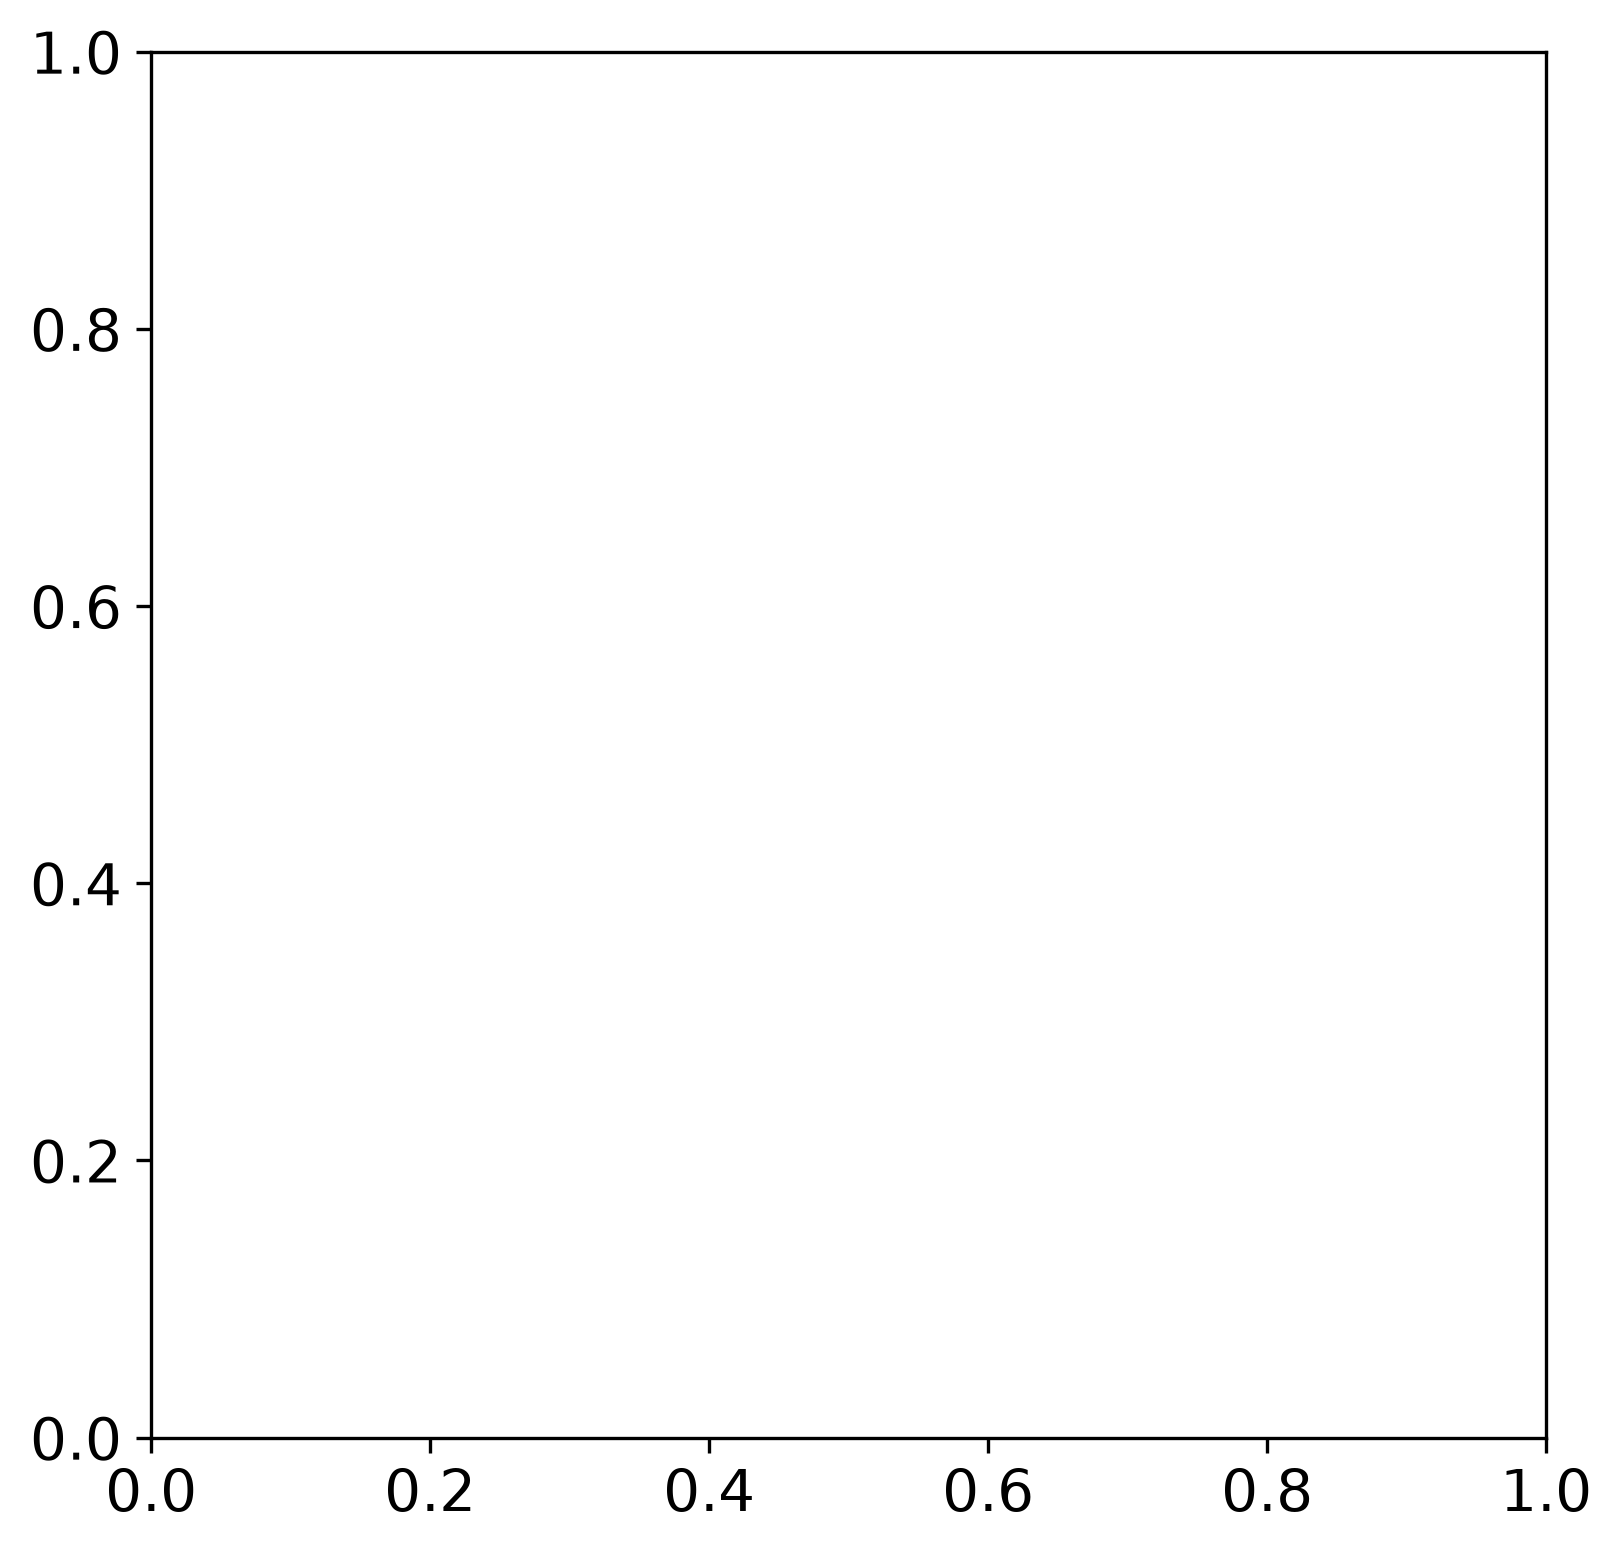

In [25]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)

# your plot here

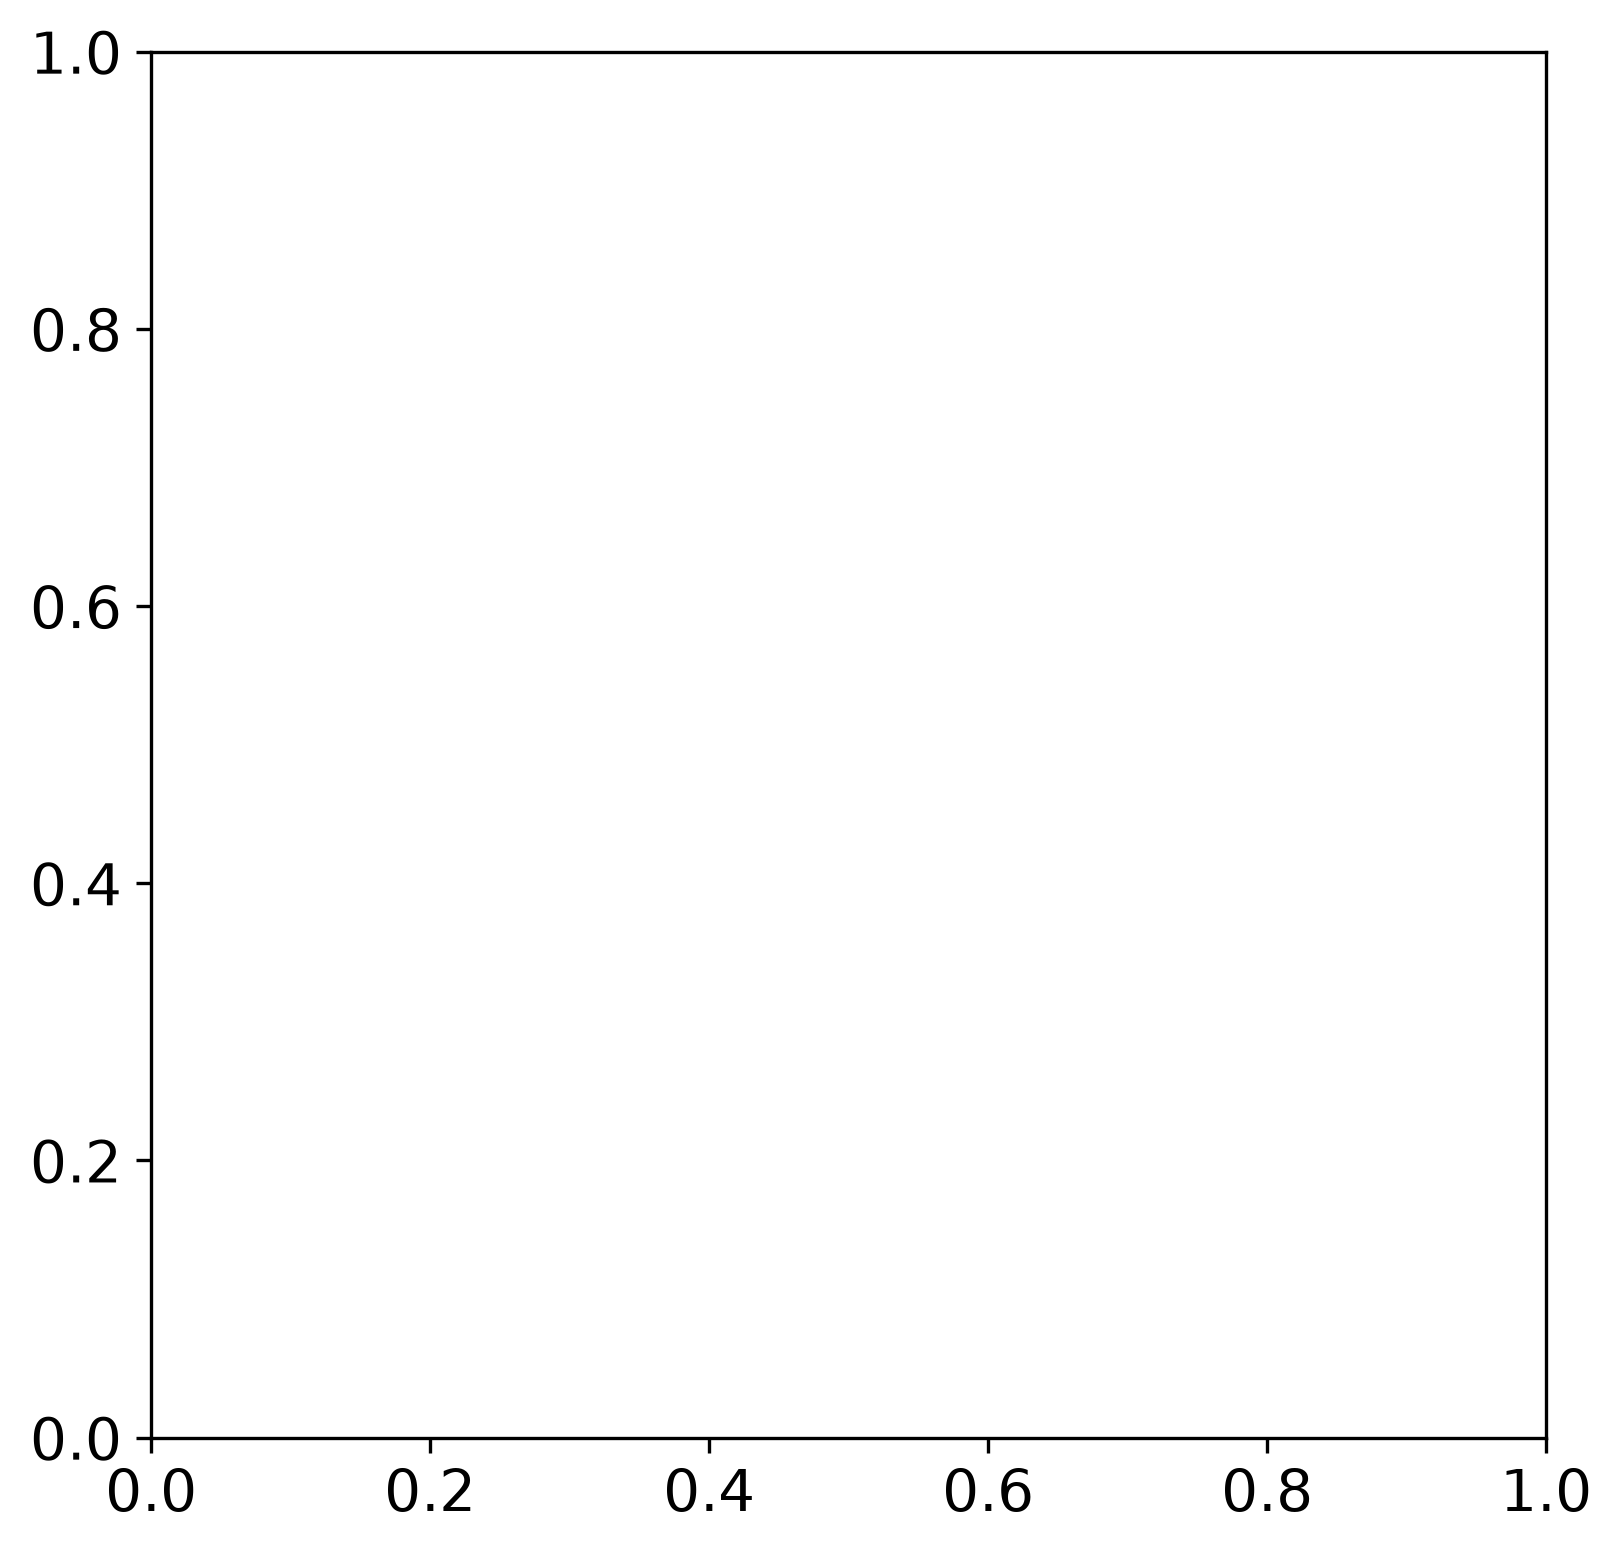

In [26]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)
ax.tick_params(labelsize=14)

ct_df_filtered = cell_types_df[cell_types_df['cell_type'].isin(['23P', 'OPC'])]
# your plot here

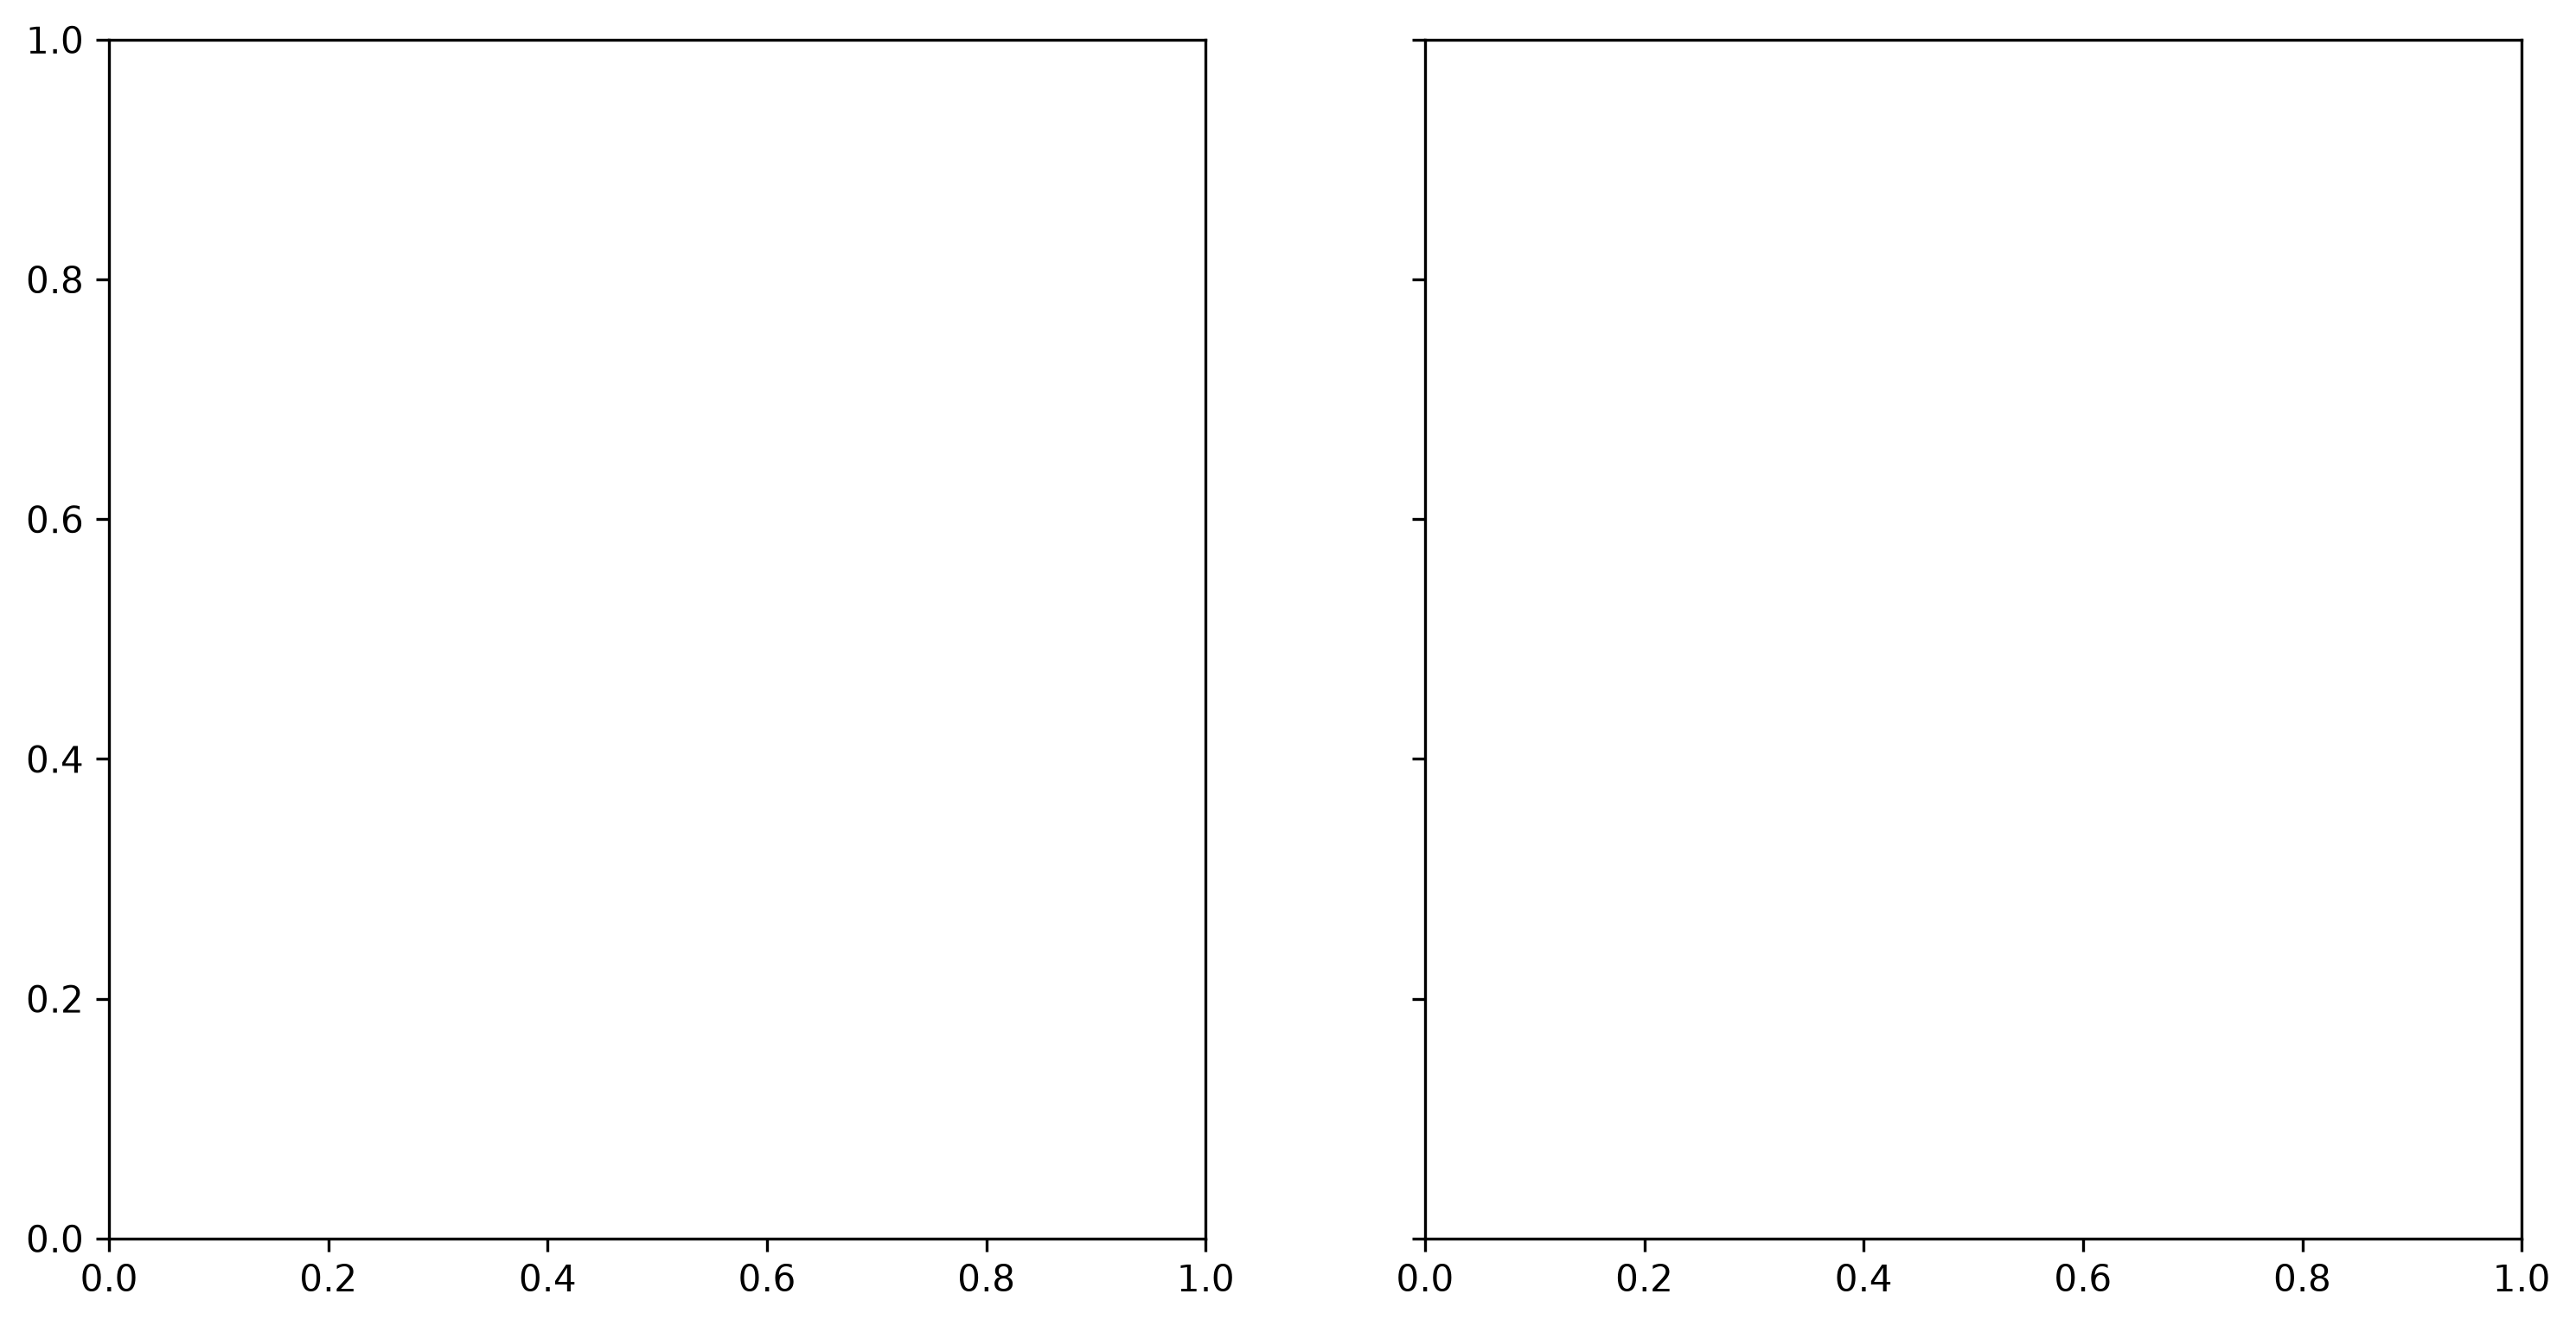

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=150, sharey=True)

# Excitatory cells
excitatory_cells_df = ...


# Inhibitory cells
inhibitory_cells_df = ...


NameError: name 'pre_syn_df' is not defined

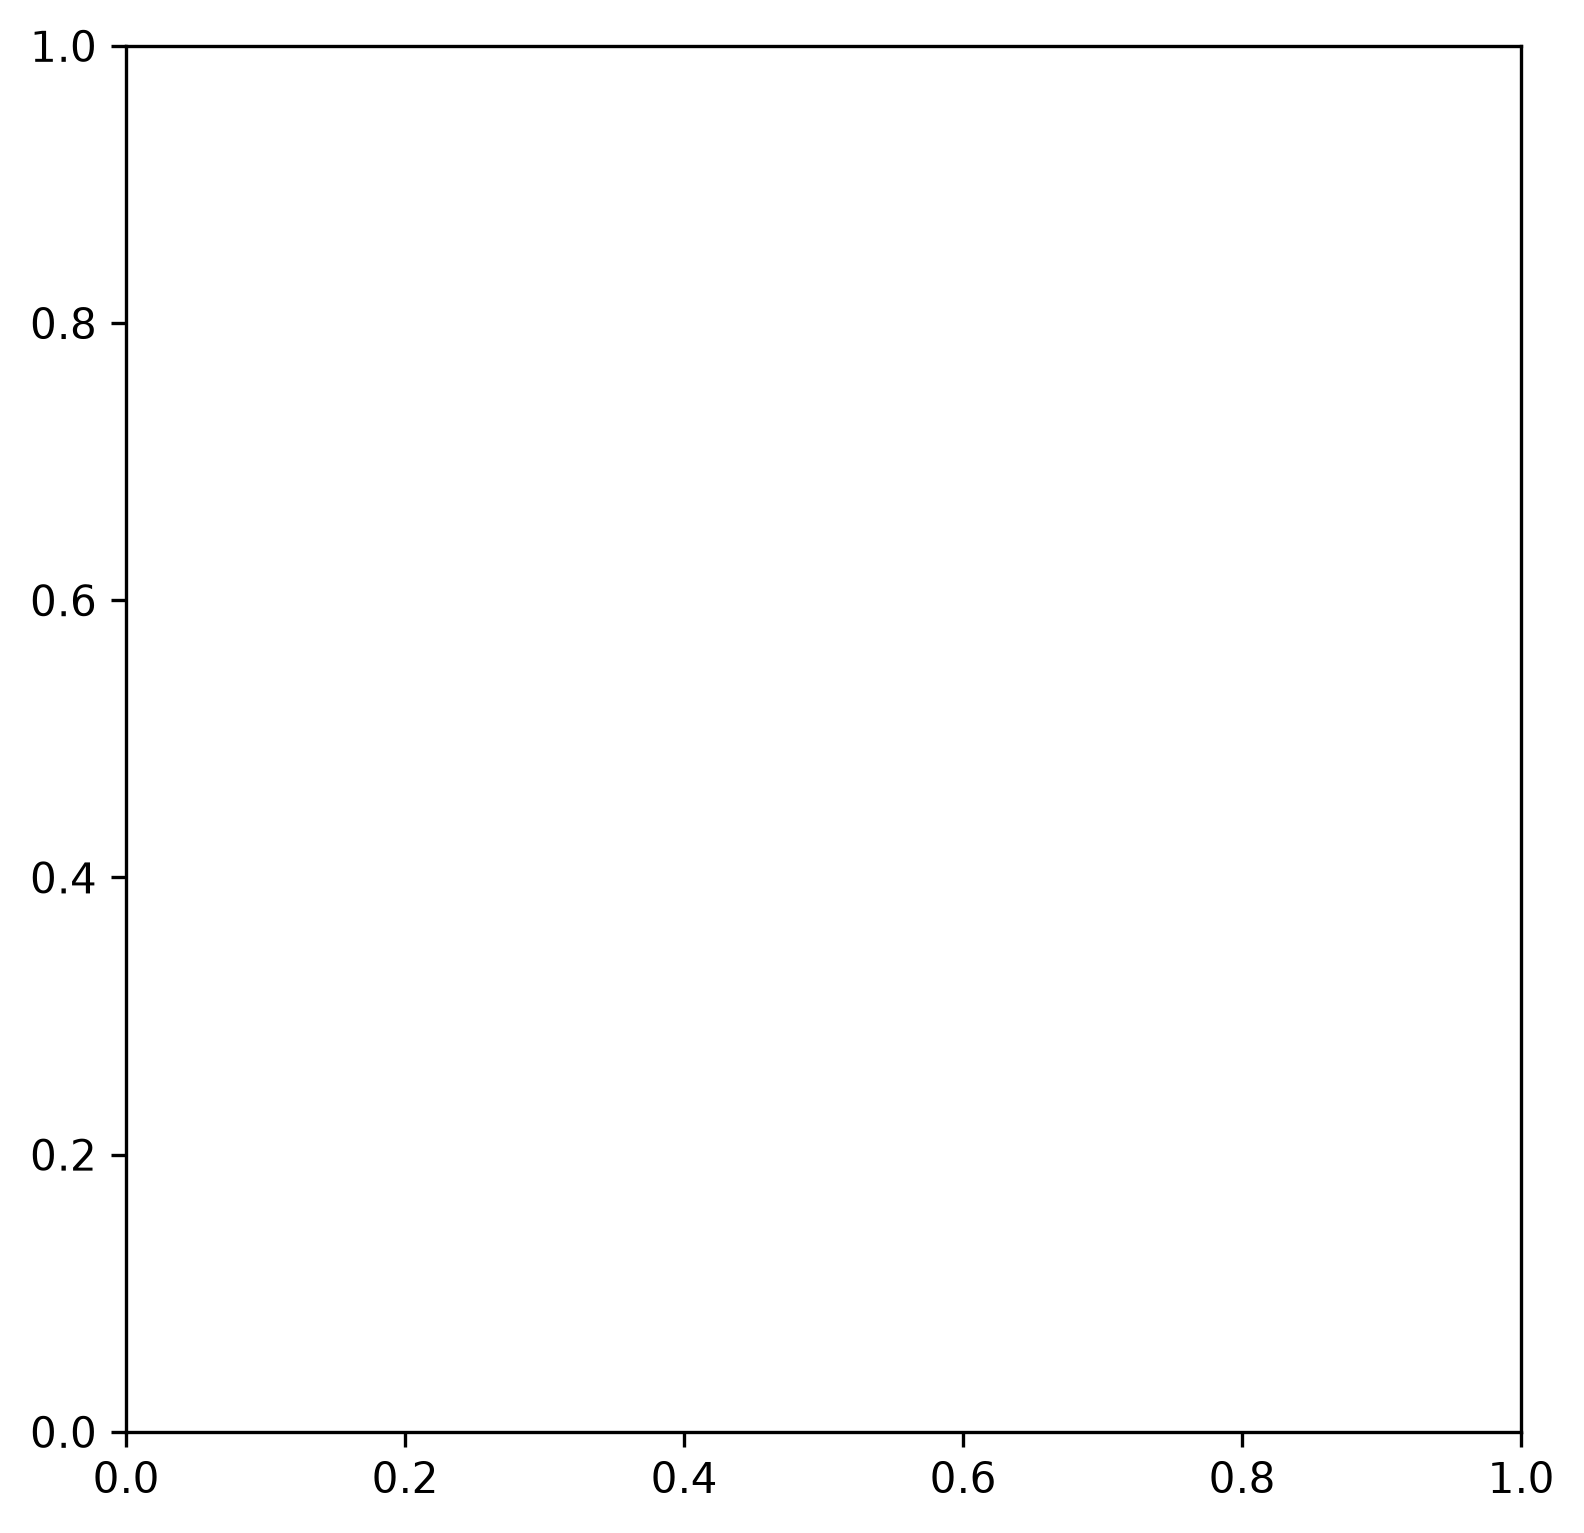

In [28]:
#Figure 14: Unique output connectivity
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=150)

# First, find the unique postsynaptic partners
unique_postsyn_partners = pre_syn_df.post_pt_root_id.unique()

# Select the cell types of the postsynaptic partners
ct_postsyn_partners = cell_types_df.loc[cell_types_df.pt_root_id.isin(unique_postsyn_partners)]

# Make a bar plot of the connections to the postsynaptic cell types
ct_summary = (pd.DataFrame(ct_postsyn_partners.value_counts('cell_type'))
              .sort_values('cell_type')
              .reset_index()
             )

f, ax = plt.subplots(1,1, figsize=(6, 6),dpi=150)
sns.barplot(ct_summary, x='cell_type', y='count', hue='cell_type', palette='tab20', ax=ax)

# Add labels to the bars
for i, r in ct_summary.iterrows():
    ax.text(i, r['count']-.1, round(r['count'], 2),
            color='white', ha='center', va='top')

plt.ylabel('Count of unique connections', fontsize = 12, labelpad=12)
plt.xlabel('Cell Type, Postsynaptic (all cells)', fontsize = 12, labelpad=12)
plt.xticks(rotation=-30, ha='left')

sns.despine()

plt.show()

NameError: name 'post_syn_df' is not defined

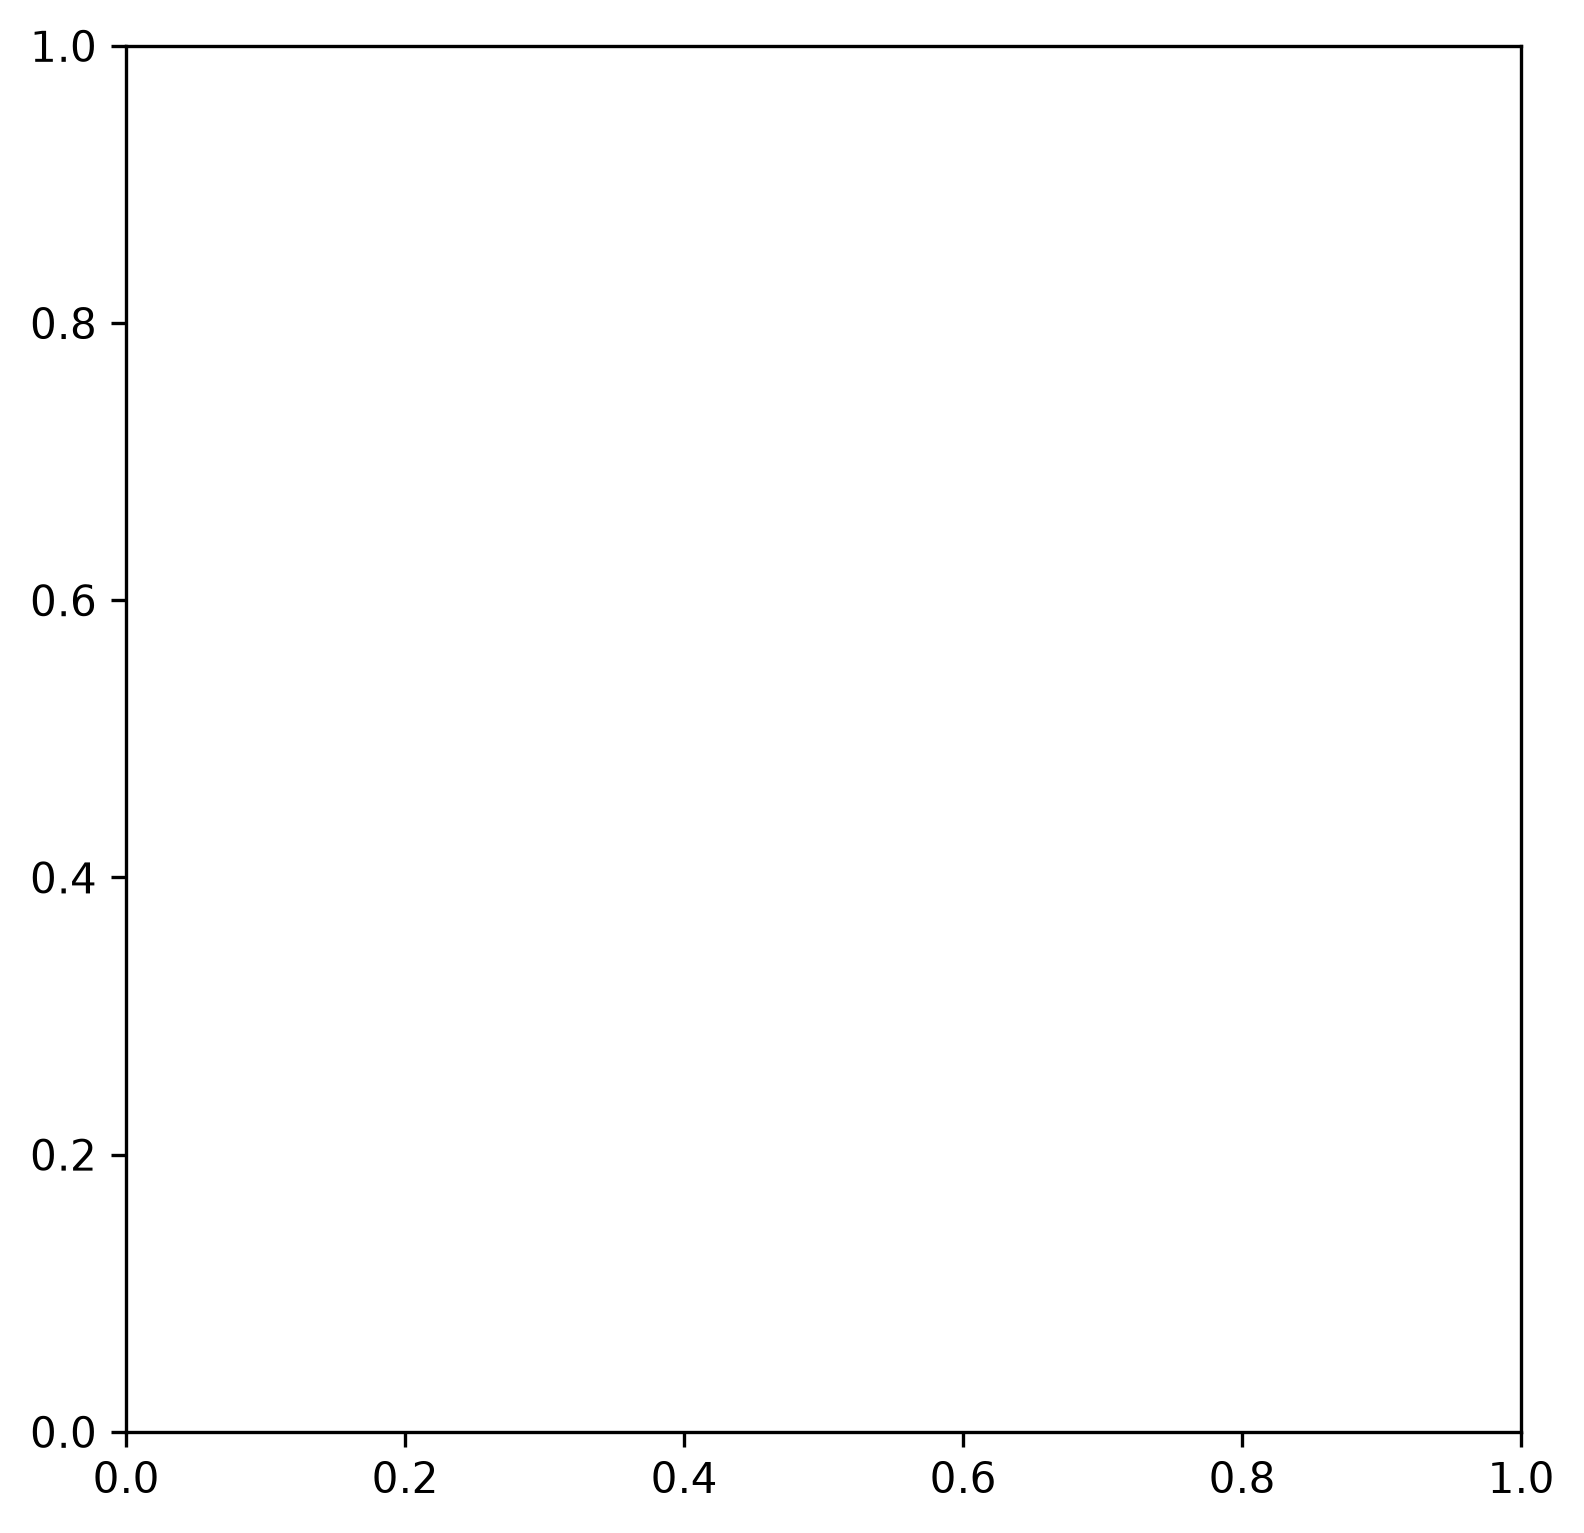

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=150)

# First, find the unique postsynaptic partners
unique_presyn_partners = post_syn_df.pre_pt_root_id.unique()

# Select the cell types of the postsynaptic partners
ct_presyn_partners = cell_types_df.loc[cell_types_df.pt_root_id.isin(unique_presyn_partners)]

# Make a bar plot of the connections to the postsynaptic cell types
ct_summary = (pd.DataFrame(ct_presyn_partners.value_counts('cell_type'))
              .sort_values('cell_type')
              .reset_index()
             )

f, ax = plt.subplots(1,1, figsize=(6, 6),dpi=150)
sns.barplot(ct_summary, x='cell_type', y='count', hue='cell_type', palette='tab20', ax=ax)

# Add labels to the bars
for i, r in ct_summary.iterrows():
    ax.text(i, r['count']-.1, round(r['count'], 2),
            color='white', ha='center', va='top')

plt.ylabel('Count of unique connections', fontsize = 12, labelpad=12)
plt.xlabel('Cell Type, Postsynaptic (all cells)', fontsize = 12, labelpad=12)
plt.xticks(rotation=-30, ha='left')

sns.despine()

plt.show()

In [30]:
# @title Helper function: sort_matrix_by_types
def sort_matrix_by_types(mat: pd.DataFrame,
                         labels: pd.DataFrame,
                         label_type_col: str = "cell_type_auto",
                         label_id_col: str = "pt_root_id",
                         post_labels: pd.DataFrame = None,
                         post_label_type_col: str = None,
                         post_label_id_col: str = None):
    """Sorts (synapse) matrix by labels.

    This function assumes a square synapse matrix!

    Args:
        mat: synapse matrix as pandas DataFrame
        labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        label_type_col: column name in labels for cell types
        label_id_col: column name in labels for root ids
        post_labels: DataFrame with labels, e.g. the output of client.materialize.query_table('aibs_metamodel_celltypes_v661')
        post_label_type_col: column name in labels for cell types
        post_label_id_col: column name in labels for root ids

    Returns:
        mat_sorted: sorted matrix
        mat_labels: sorted labels; has the same length as matrix
    """

    if post_labels is None:
        post_labels = labels
    if post_label_type_col is None:
        post_label_type_col = label_type_col
    if post_label_id_col is None:
        post_label_id_col = label_id_col

    mat_sorted = mat.copy()

    pre_mat_labels = np.array(labels.set_index(label_id_col).loc[mat_sorted.index][label_type_col])
    pre_sorting = np.argsort(pre_mat_labels)

    post_mat_labels = np.array(post_labels.set_index(post_label_id_col).loc[mat_sorted.T.index][post_label_type_col])
    post_sorting = np.argsort(post_mat_labels)

    mat_sorted = mat_sorted.iloc[pre_sorting].T.iloc[post_sorting].T

    return mat_sorted, pre_mat_labels[pre_sorting], post_mat_labels[post_sorting]

In [31]:
# Sort the column connectivity (binary: connected or not)
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: (np.sum(x) > 0)).fillna(0)

syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# sort the matrix by cell types to render sensibly in heatmap
cell_types_df = cell_types_df.fillna({'cell_type': 'unknown', 'broad_type': 'unknown', 'meso_type': 'unknown'})
syn_mat_ct, syn_mat_cell_types, _ = sort_matrix_by_types(syn_mat, cell_types_df, label_type_col="cell_type")

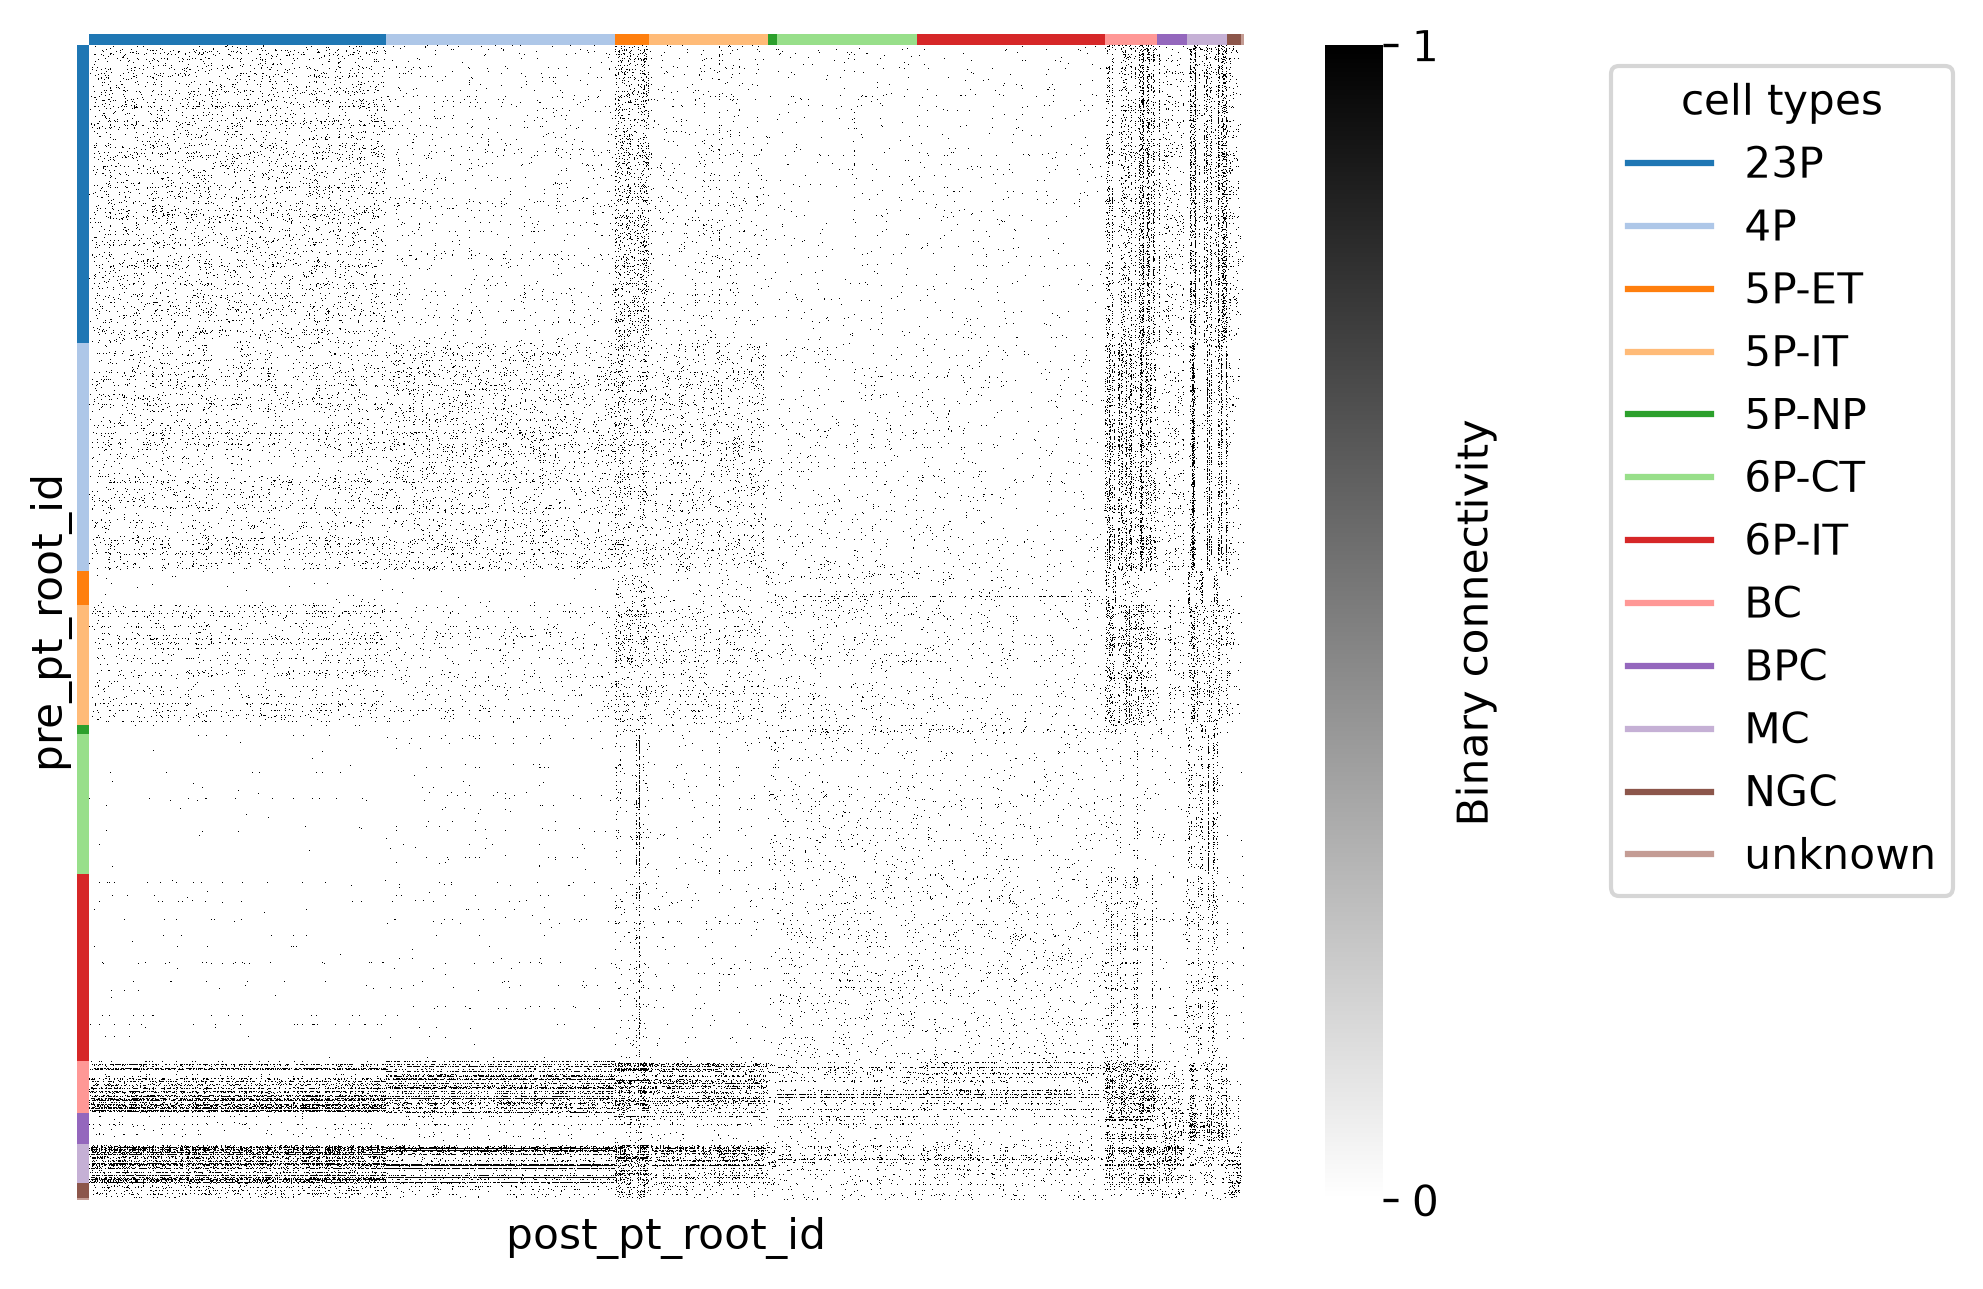

In [32]:
# @title Figure 8: Connectivity matrix sorted by cell type

# add colormap for cell type
cts, ct_idx = np.unique(syn_mat_cell_types, return_inverse=True)
ct_colors = plt.get_cmap("tab20")(ct_idx)

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
sns.heatmap(syn_mat_ct, cmap="gray_r", xticklabels=[], yticklabels=[],
            ax=ax, square=True,
            cbar_kws={"label": "Binary connectivity", "ticks": [0, 1]})


# Adding row and column colors for cell types
for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(-0.01, i), width=0.01, height=1, color=color, lw=0,
                               transform=ax.get_yaxis_transform(), clip_on=False))

for i, color in enumerate(ct_colors):
    ax.add_patch(plt.Rectangle(xy=(i, 1), height=0.01, width=1, color=color, lw=0,
                               transform=ax.get_xaxis_transform(), clip_on=False))

import matplotlib
# add a legend for the cell types
legend_elements = [matplotlib.lines.Line2D([0], [0], color=plt.get_cmap("tab20")(i), label=ct) for i, ct in enumerate(cts)]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.3, 1), title="cell types")
plt.show()

In [33]:
# extract only the synapses between excitatory-excitatory cells in the column
excitatory_root_ids = cell_types_df.query("broad_type=='excitatory'").pt_root_id.to_numpy()

# Filter synapse table for excitatory-excitatory connections
exc_exc_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(excitatory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(excitatory_root_ids)
                                                 )]

np.shape(exc_exc_synapses)

(36233, 6)

[Text(0.5, 0, 'Sum synapse size (voxels - log scale)'),
 Text(0, 0.5, 'Number of connections')]

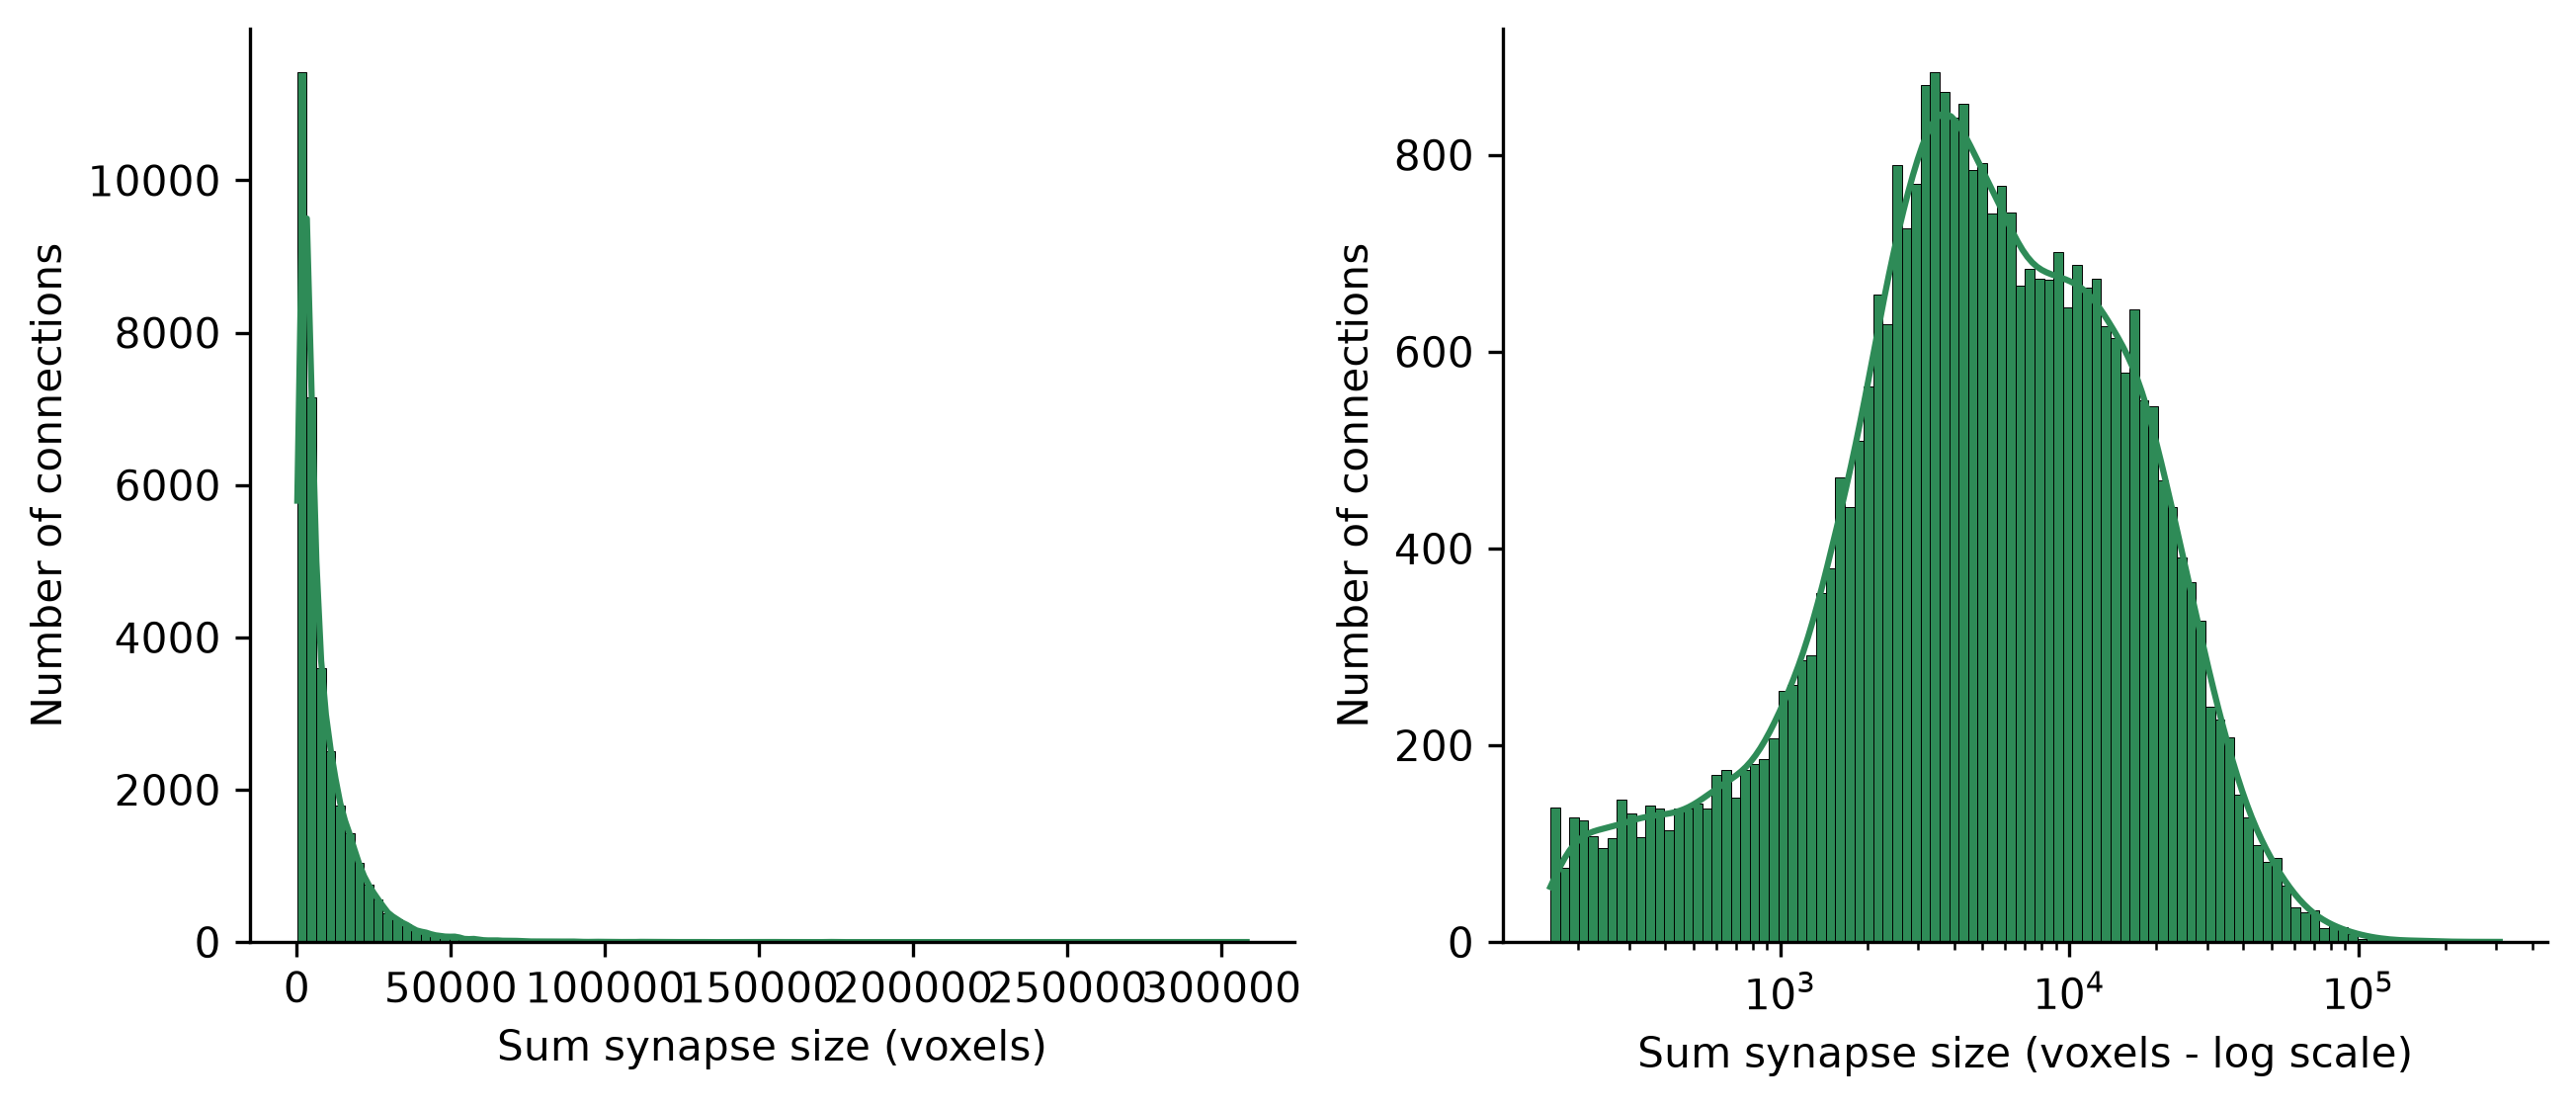

In [34]:
# @title Figure 9: Synapse size excitatory-to-excitatory connections

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

syn_mat = exc_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: (np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# collect the synaptic weights that are non-zero
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=False,
    facecolor='seagreen',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=True,
    facecolor='seagreen',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")

In [35]:
# matrix of log-summed synapse size
syn_mat_logsum = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: np.log(np.sum(x))).fillna(0)

# Make sure matrix is quadratic
syn_mat_logsum = syn_mat_logsum.reindex(columns=np.array(syn_mat.index)).astype(float)


Number of edges: 58840
Number of possible edges: 1611095
Fraction of possible edges: 0.0365


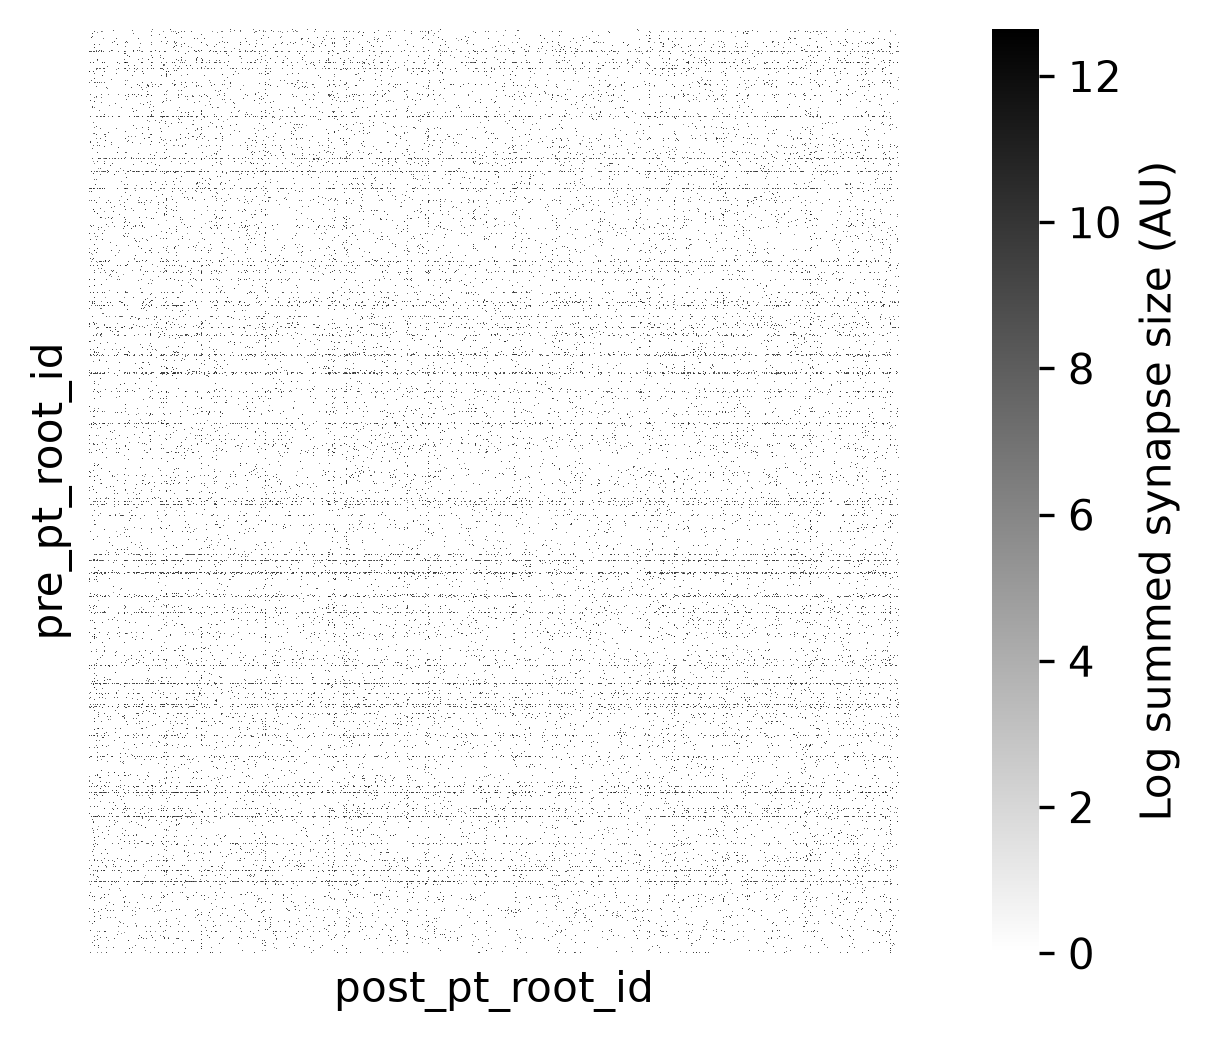

In [36]:
# @title Figure 10: Connectivity matrix, with synaptic strength (column-to-column)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.heatmap(syn_mat_logsum, cmap="gray_r", xticklabels=[], yticklabels=[],
            ax=ax, square=True,
            cbar_kws={"label": "Log summed synapse size (AU)"})


row_indices, column_indices = np.nonzero(syn_mat_logsum)
n_edges = len(row_indices)
n_possible_edges = syn_mat_logsum.shape[0] * syn_mat_logsum.shape[1]
print(f"Number of edges: {n_edges}")
print(f"Number of possible edges: {n_possible_edges}")
print(f"Fraction of possible edges: {n_edges / n_possible_edges:.4f}")

In [37]:
# Filter synapse table for inhibitory-excitatory connections
inhibitory_root_ids = cell_types_df.query("broad_type=='inhibitory'").pt_root_id.to_numpy()
inh_exc_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(inhibitory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(excitatory_root_ids)
                                                 )]
np.shape(inh_exc_synapses)

(72765, 6)

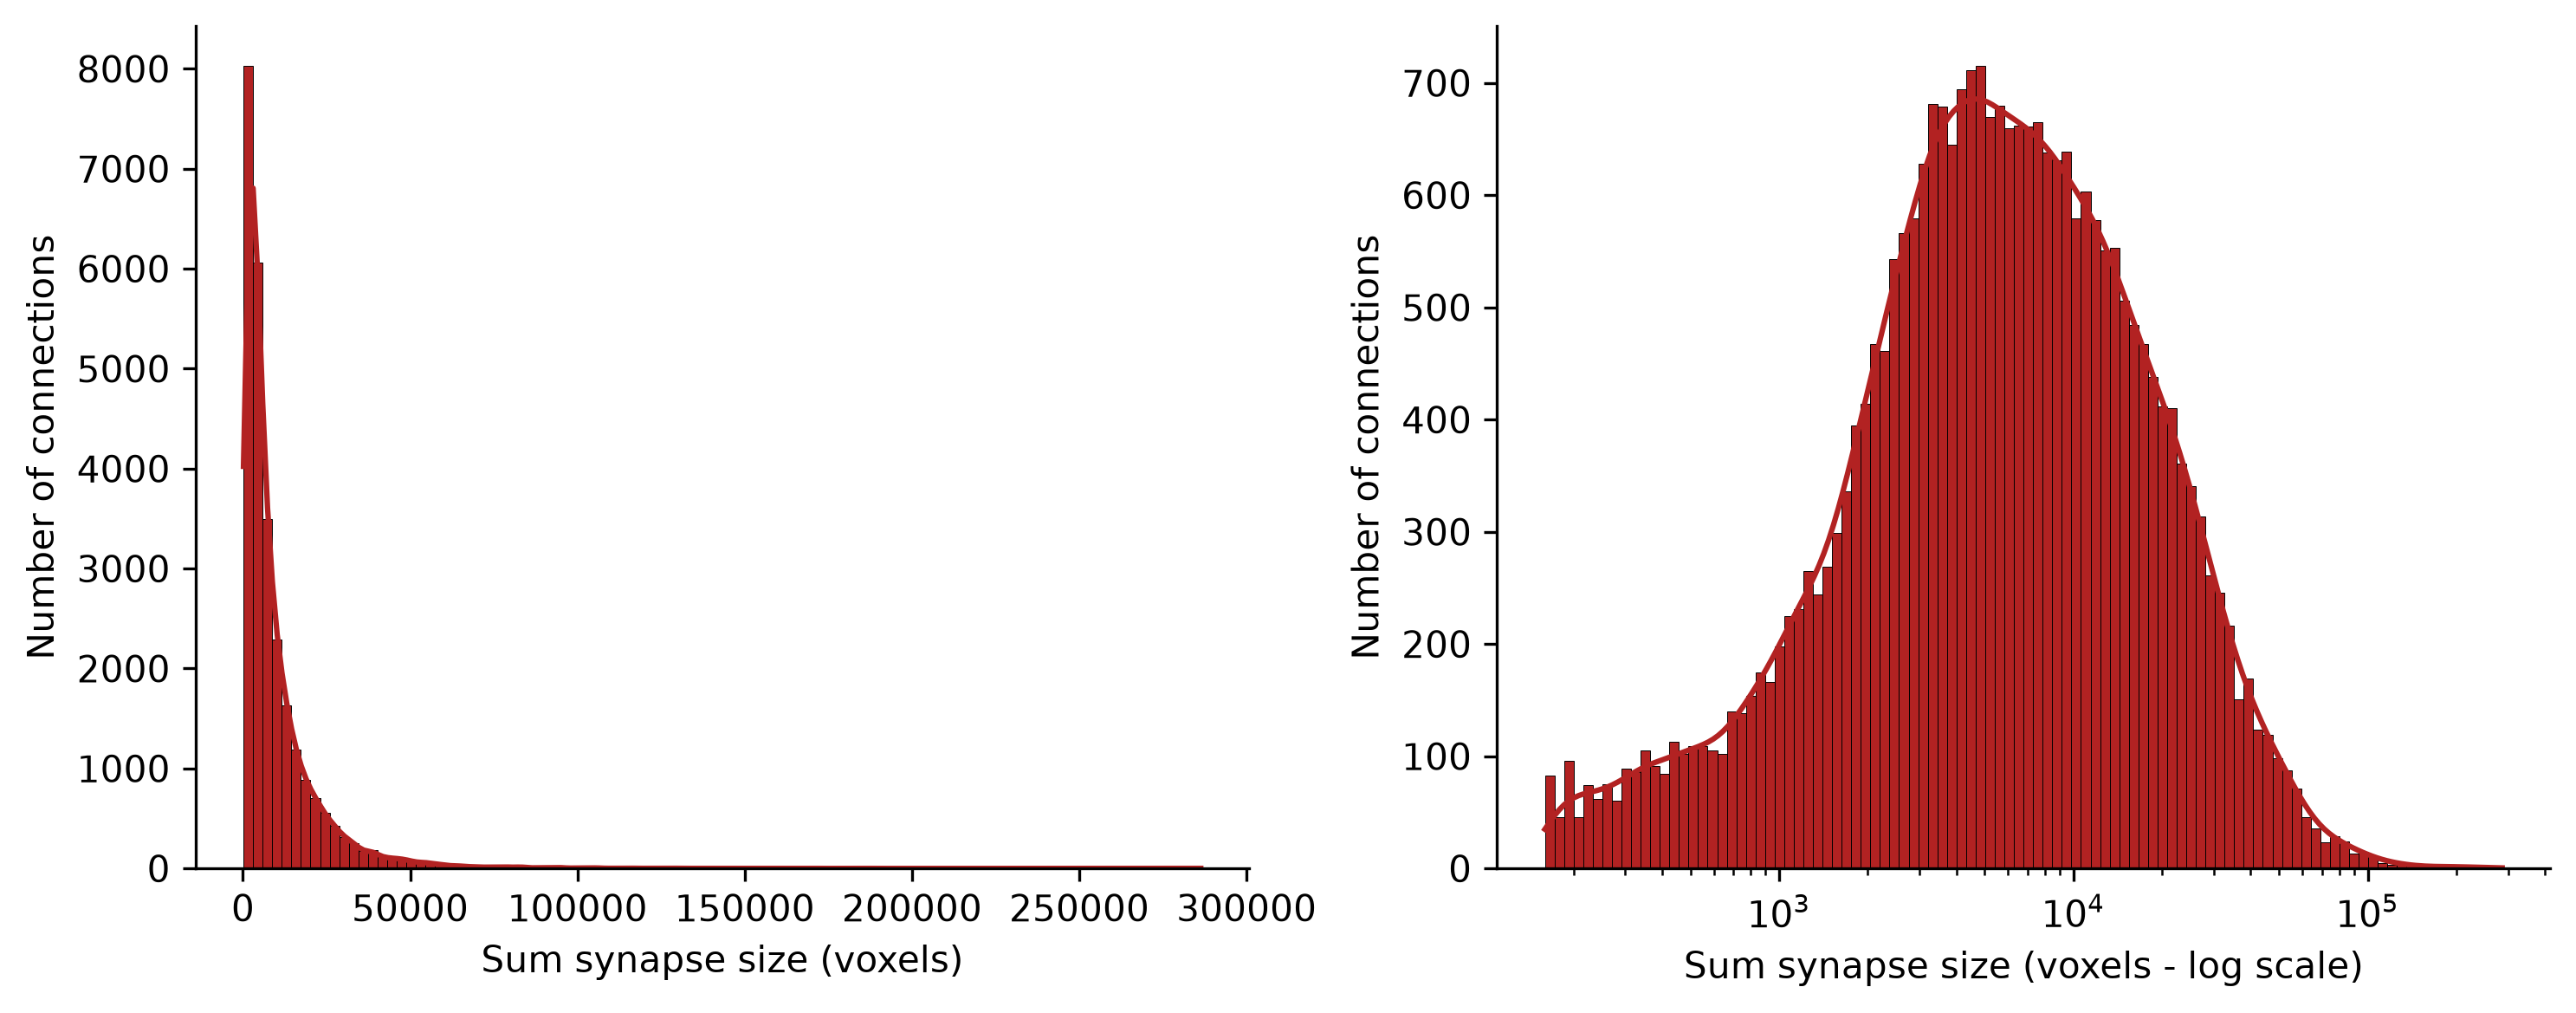

In [38]:
# @title Figure 9b: Synapse size inhibitory-to-inhibitory connections

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

syn_mat = inh_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: (np.sum(x))).fillna(0)

# This matrix will NOT be quadratic. this line is unnecessary
# syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

# collect the synaptic weights that are non-zero
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

# Histogram on linear-x
ax = axs[0]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=False,
    facecolor='firebrick',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels)", ylabel="Number of connections")

# Histogram on log-x
ax = axs[1]
sns.histplot(
    edge_weights,
    kde=True,
    bins=100,
    ax=ax,
    log_scale=True,
    facecolor='firebrick',
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Sum synapse size (voxels - log scale)", ylabel="Number of connections")
plt.tight_layout()
plt.show()

In [39]:
# Filter synapse table for inhibitory-inhibitory connections
inhibitory_root_ids = cell_types_df.query("broad_type=='inhibitory'").pt_root_id.to_numpy()
inh_inh_synapses = column_synapses.loc[(column_synapses.pre_pt_root_id.isin(inhibitory_root_ids) &
                                        column_synapses.post_pt_root_id.isin(inhibitory_root_ids)
                                                 )]
np.shape(inh_inh_synapses)

(9417, 6)

[Text(0.5, 0, 'Number of synapses per connection'),
 Text(0, 0.5, 'Number of connections')]

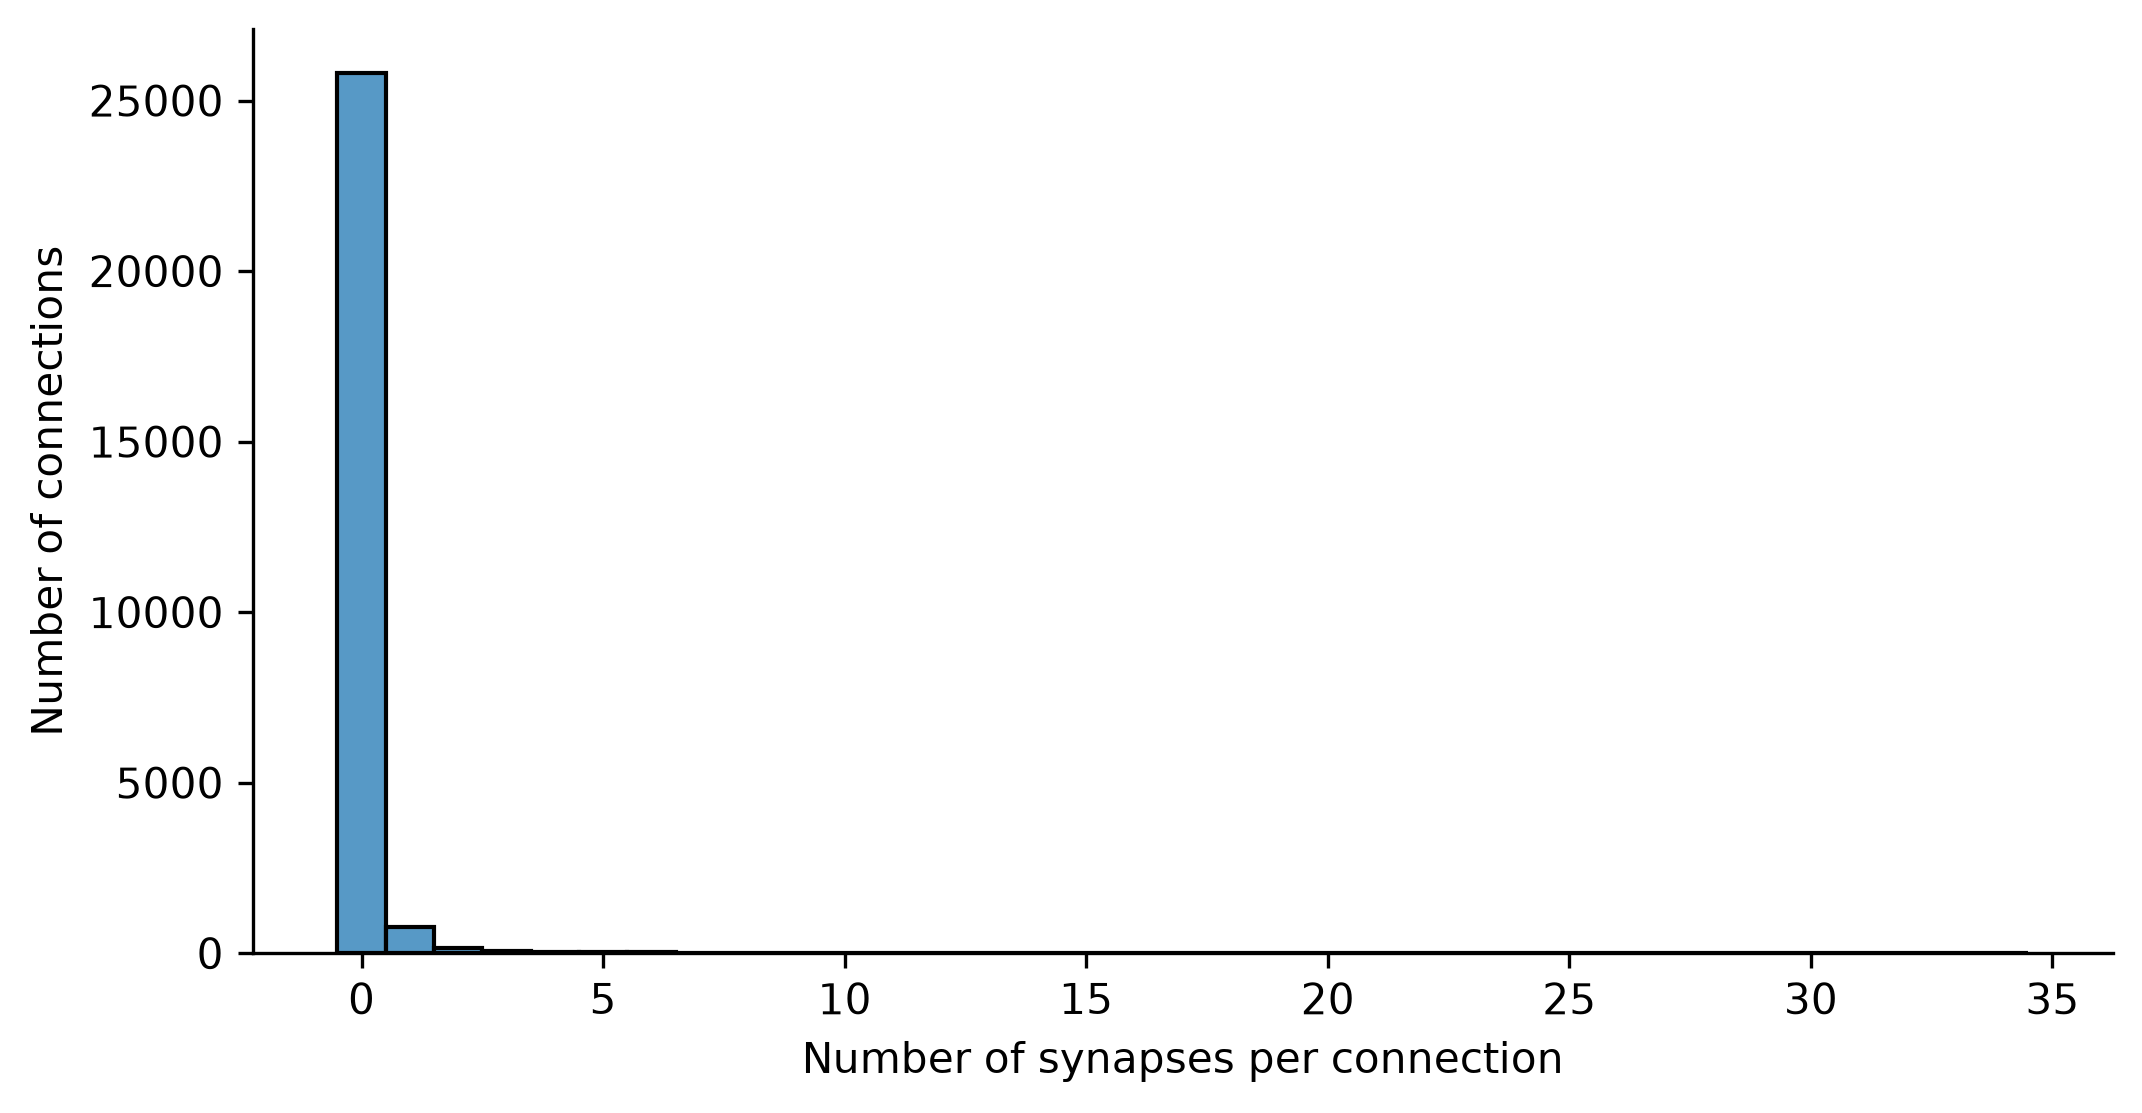

In [40]:
# @title Figure 11: Synapse count per connection

# Count Histogram on linear-x
syn_mat = column_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                            values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)

# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]
sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set(xlabel="Number of synapses per connection", ylabel="Number of connections")

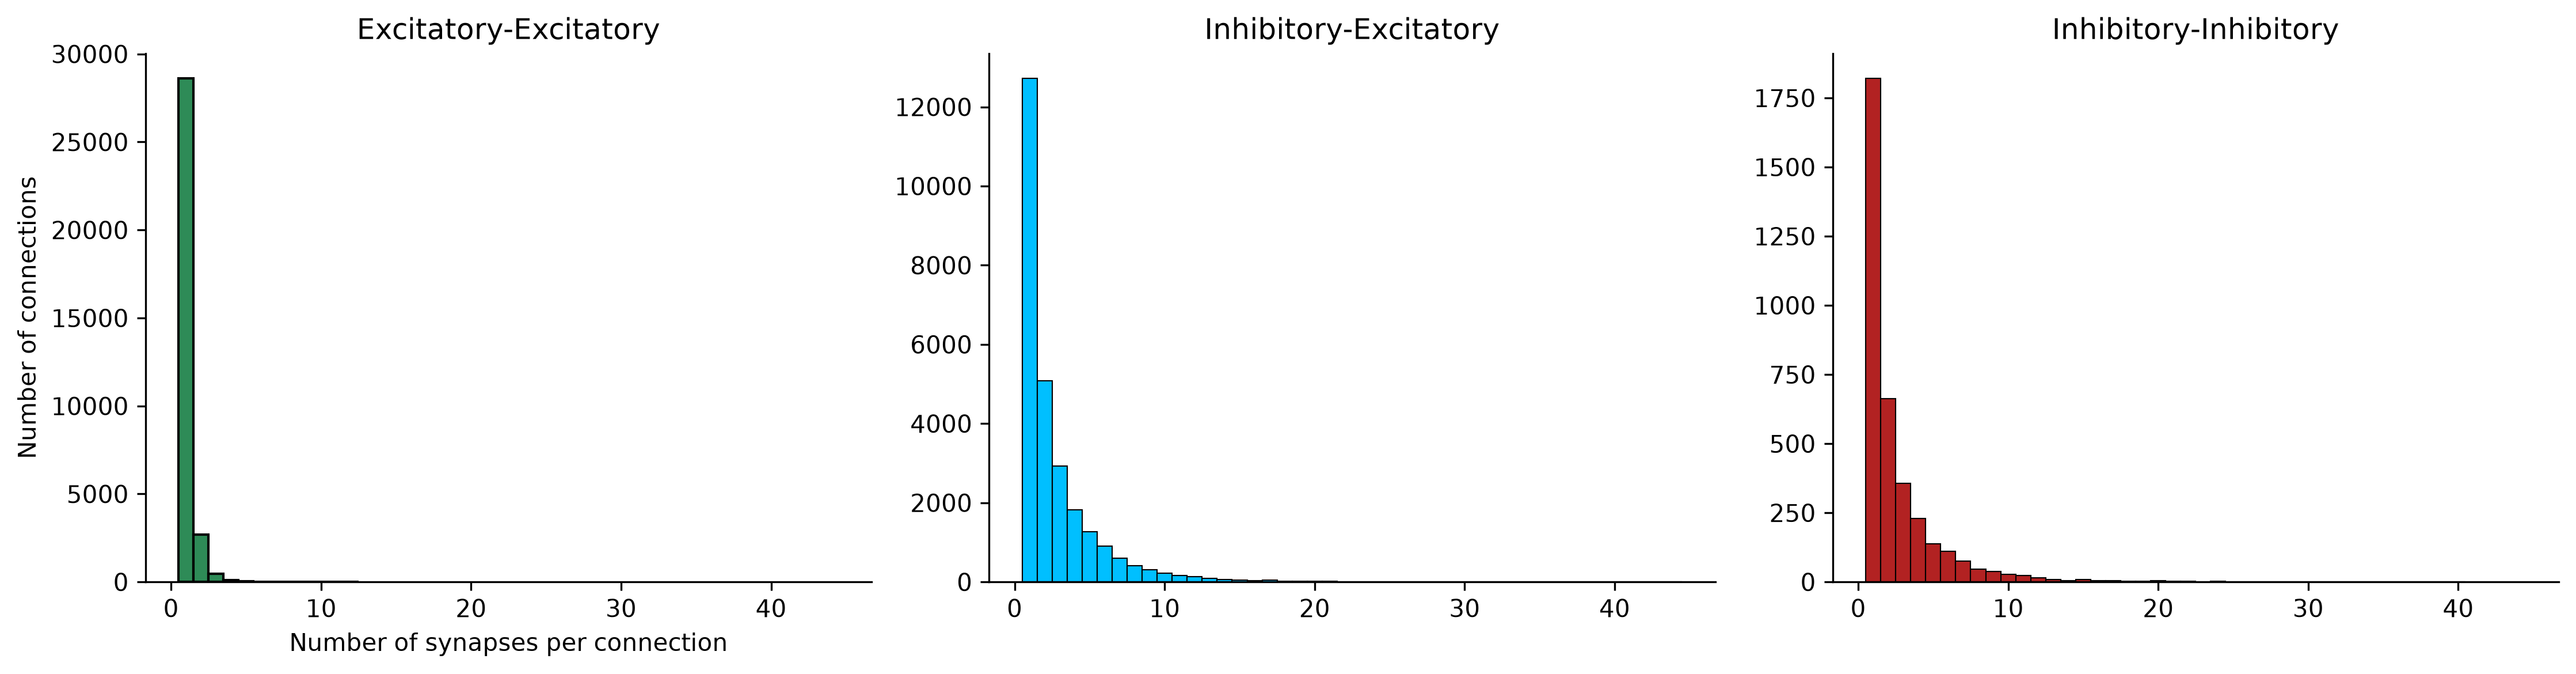

In [41]:
# @title Figure 12: Synapse count per connection differs for excitatory or inhibitory connections

fig, ax = plt.subplots(1,3, figsize=(15, 4),dpi=150, sharex=True)

syn_mat = exc_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[0],
    facecolor='seagreen',
)


syn_mat = inh_exc_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
## This matrix cannot be quadratic
# syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[1],
    facecolor='deepskyblue',
)

# Added code for Inhibitory-Inhibitory plot (Can be delegated as student task)
syn_mat = inh_inh_synapses.pivot_table(index="pre_pt_root_id", columns="post_pt_root_id",
                                       values="size", aggfunc=lambda x: np.sum(x > 0)).fillna(0)
# Make sure matrix is quadratic
syn_mat = syn_mat.reindex(columns=np.array(syn_mat.index)).astype(float)
row_indices, column_indices = np.nonzero(syn_mat)
edge_weights = syn_mat.to_numpy()[row_indices, column_indices]

sns.histplot(
    edge_weights,
    discrete=True,
    ax=ax[2],
    facecolor='firebrick',
)

sns.despine()
ax[0].set(title='Excitatory-Excitatory', xlabel="Number of synapses per connection", ylabel="Number of connections")
ax[1].set(title='Inhibitory-Excitatory', ylabel=None)
ax[2].set(title='Inhibitory-Inhibitory', ylabel=None)

plt.tight_layout()

In [42]:
# Synapse dataframe attached to skeleton
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes

# Add spine information to outputs
output_synapse_tags = client.materialize.tables.synapse_target_predictions_ssa_v2(id=pre_syn_df.index).query(
    select_columns={'synapses_pni_2': ['id'], # reference id for synapse table
                    'synapse_target_predictions_ssa_v2': ['tag'], # compartment label
                   }
).set_index('id')

pre_syn_df = (pre_syn_df.merge(output_synapse_tags, left_index=True, right_index=True, how='left')
              .rename(columns={'tag': 'Target'})
              .fillna({'Target': 'none'})
             )

# Add spine information to inputs
input_synapse_tags = client.materialize.tables.synapse_target_predictions_ssa_v2(id=post_syn_df.index).query(
    select_columns={'synapses_pni_2': ['id'], # reference id for synapse table
                    'synapse_target_predictions_ssa_v2': ['tag'], # compartment label
                   }
).set_index('id')

post_syn_df = (post_syn_df.merge(input_synapse_tags, left_index=True, right_index=True, how='left')
               .rename(columns={'tag': 'Target'})
               .fillna({'Target': 'none'})
             )


NameError: name 'cell' is not defined

NameError: name 'cell' is not defined

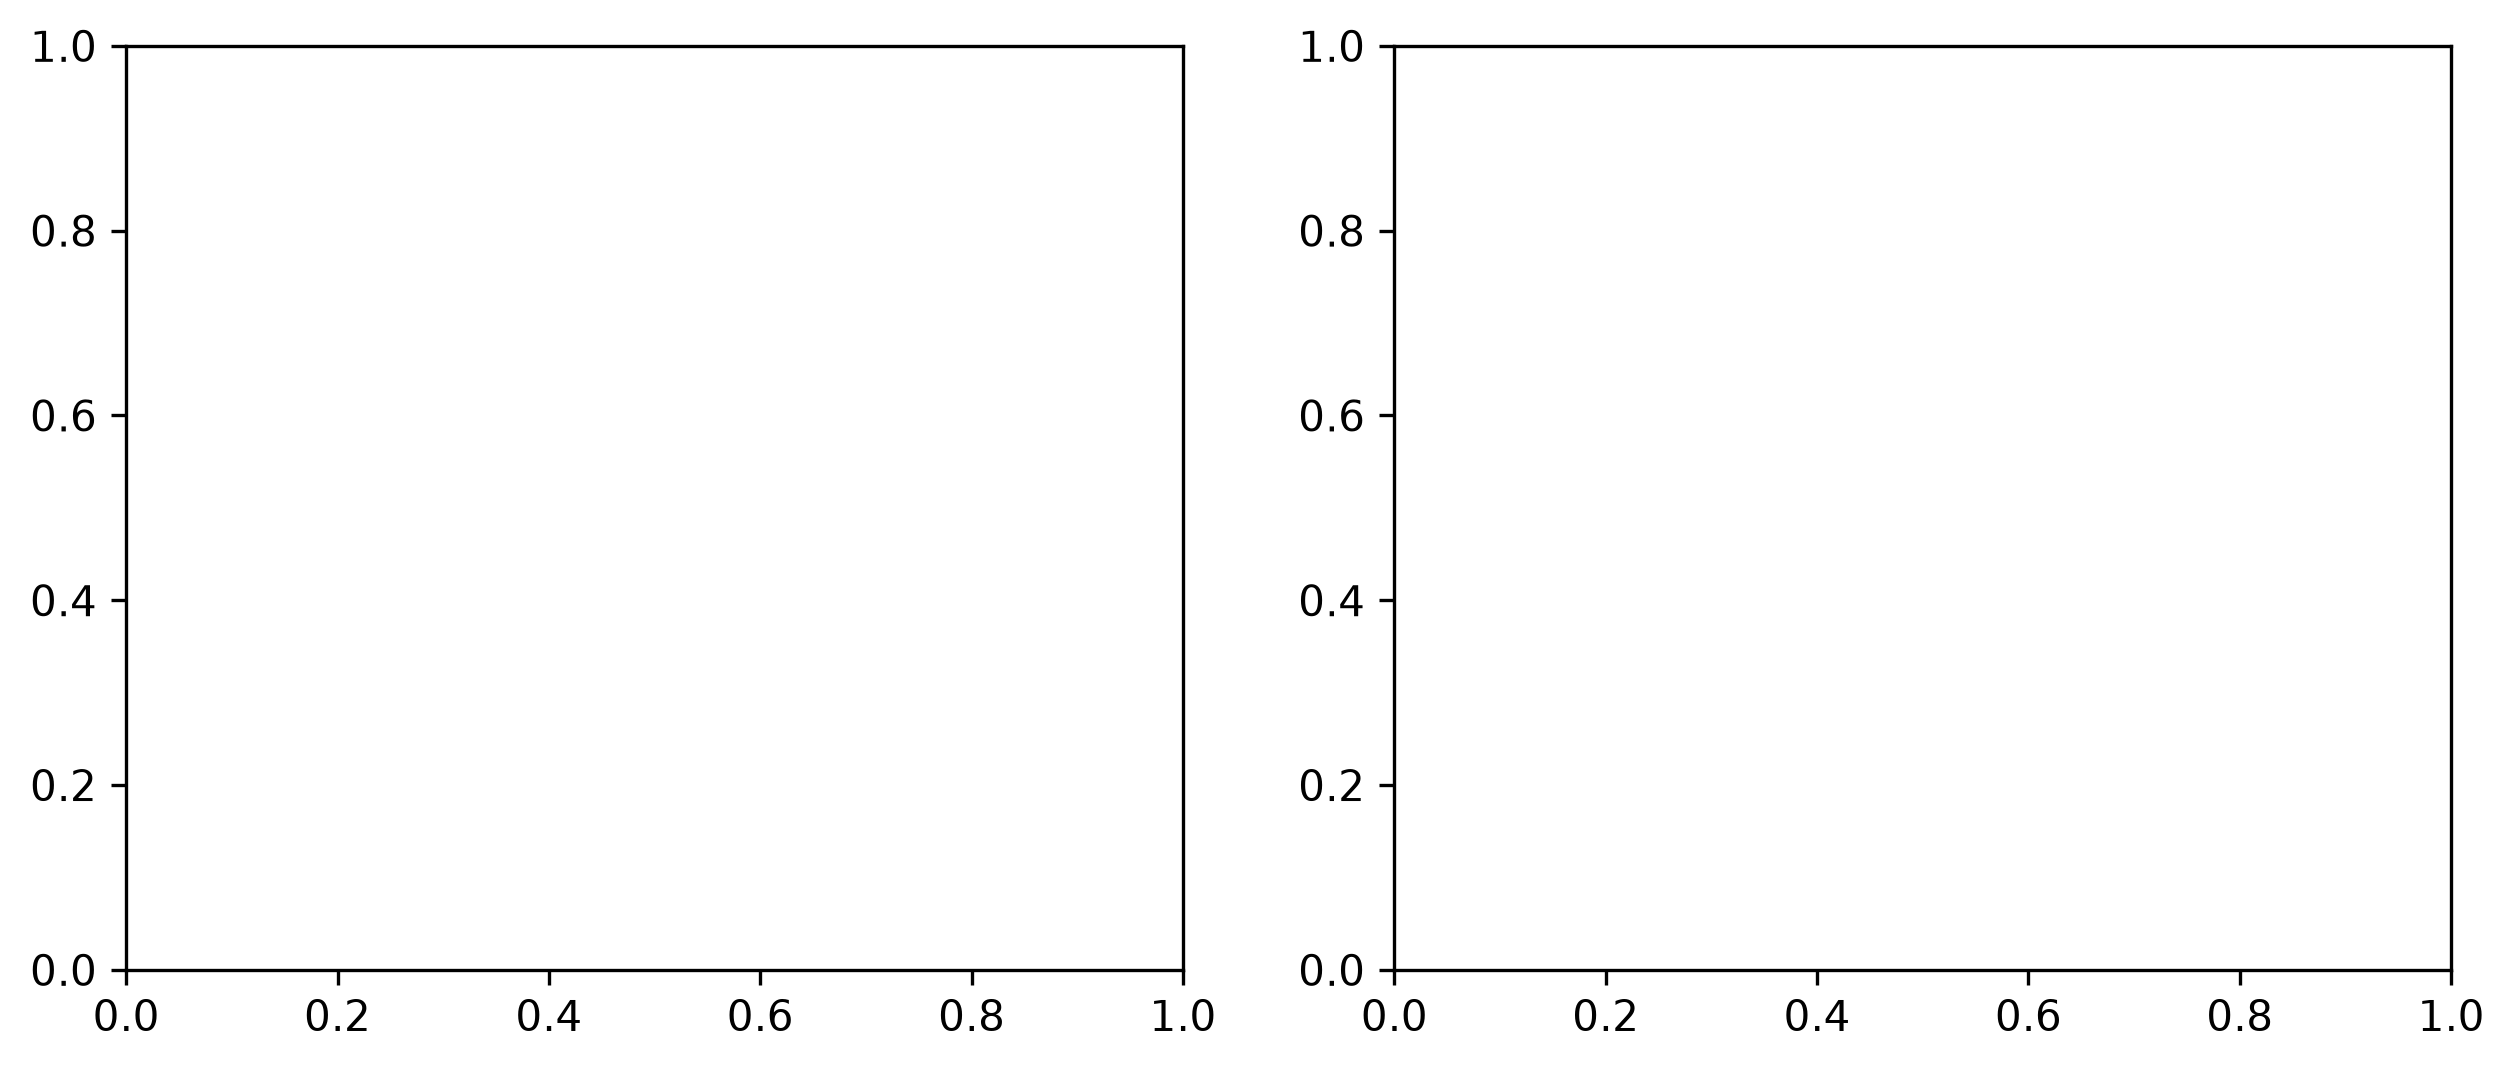

In [43]:
# @title Figure 4: Synaptic target compartments: spine, shaft, soma

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

point_size = 3

for i in range(2):
    ossify.plot.plot_morphology_2d(cell,
                                   projection="xy",
                                   color="compartment",
                                   palette={ossify.SWC_SOMA: 'navy', ossify.SWC_AXON: 'dimgrey', ossify.SWC_DENDRITE: 'black'},  # SWC compartment codes (soma/axon/dendrite)
                                   linewidth="radius",            # line thickness follows neurite radius
                                   linewidth_norm=(100, 1000),    # radii (nm) mapped to the widths below
                                   widths=(0.25, 2),
                                   ax=ax[i])
# Output synapses
sns.scatterplot(data=pre_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, hue='Target', hue_order=['spine','shaft','soma','none'],
                palette={'spine': 'deeppink','shaft': 'gold', 'soma':'cyan', 'none': 'lightgrey'},
                ax=ax[0], edgecolor=None, zorder=100)


# Input synapses
sns.scatterplot(data=post_syn_df, x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=point_size, hue='Target', hue_order=['spine','shaft','soma','none'],
                palette={'spine': 'deeppink','shaft': 'gold', 'soma':'cyan', 'none': 'lightgrey'},
                ax=ax[1], edgecolor=None, zorder=100)


ax[0].set(title="Output Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Input Synapses", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
plt.show()

In [44]:
# Reuse the cell loaded in Part 1 — it already has the skeleton and synapses,
# so there is no need to fetch it again.
pre_syn_df = cell.annotations.pre_syn.nodes
post_syn_df = cell.annotations.post_syn.nodes


NameError: name 'cell' is not defined

In [45]:
### Calculate synapse distance to root

# Convert annotations to positional indices for algorithm
post_syn_indices = cell.annotations.post_syn.map_index_to_layer(
    "skeleton", as_positional=True
)
# compute distance to root for every annotation
distances_to_root = cell.skeleton.distance_to_root(post_syn_indices)
post_syn_df['distance_to_root'] = distances_to_root


NameError: name 'cell' is not defined

NameError: name 'cell' is not defined

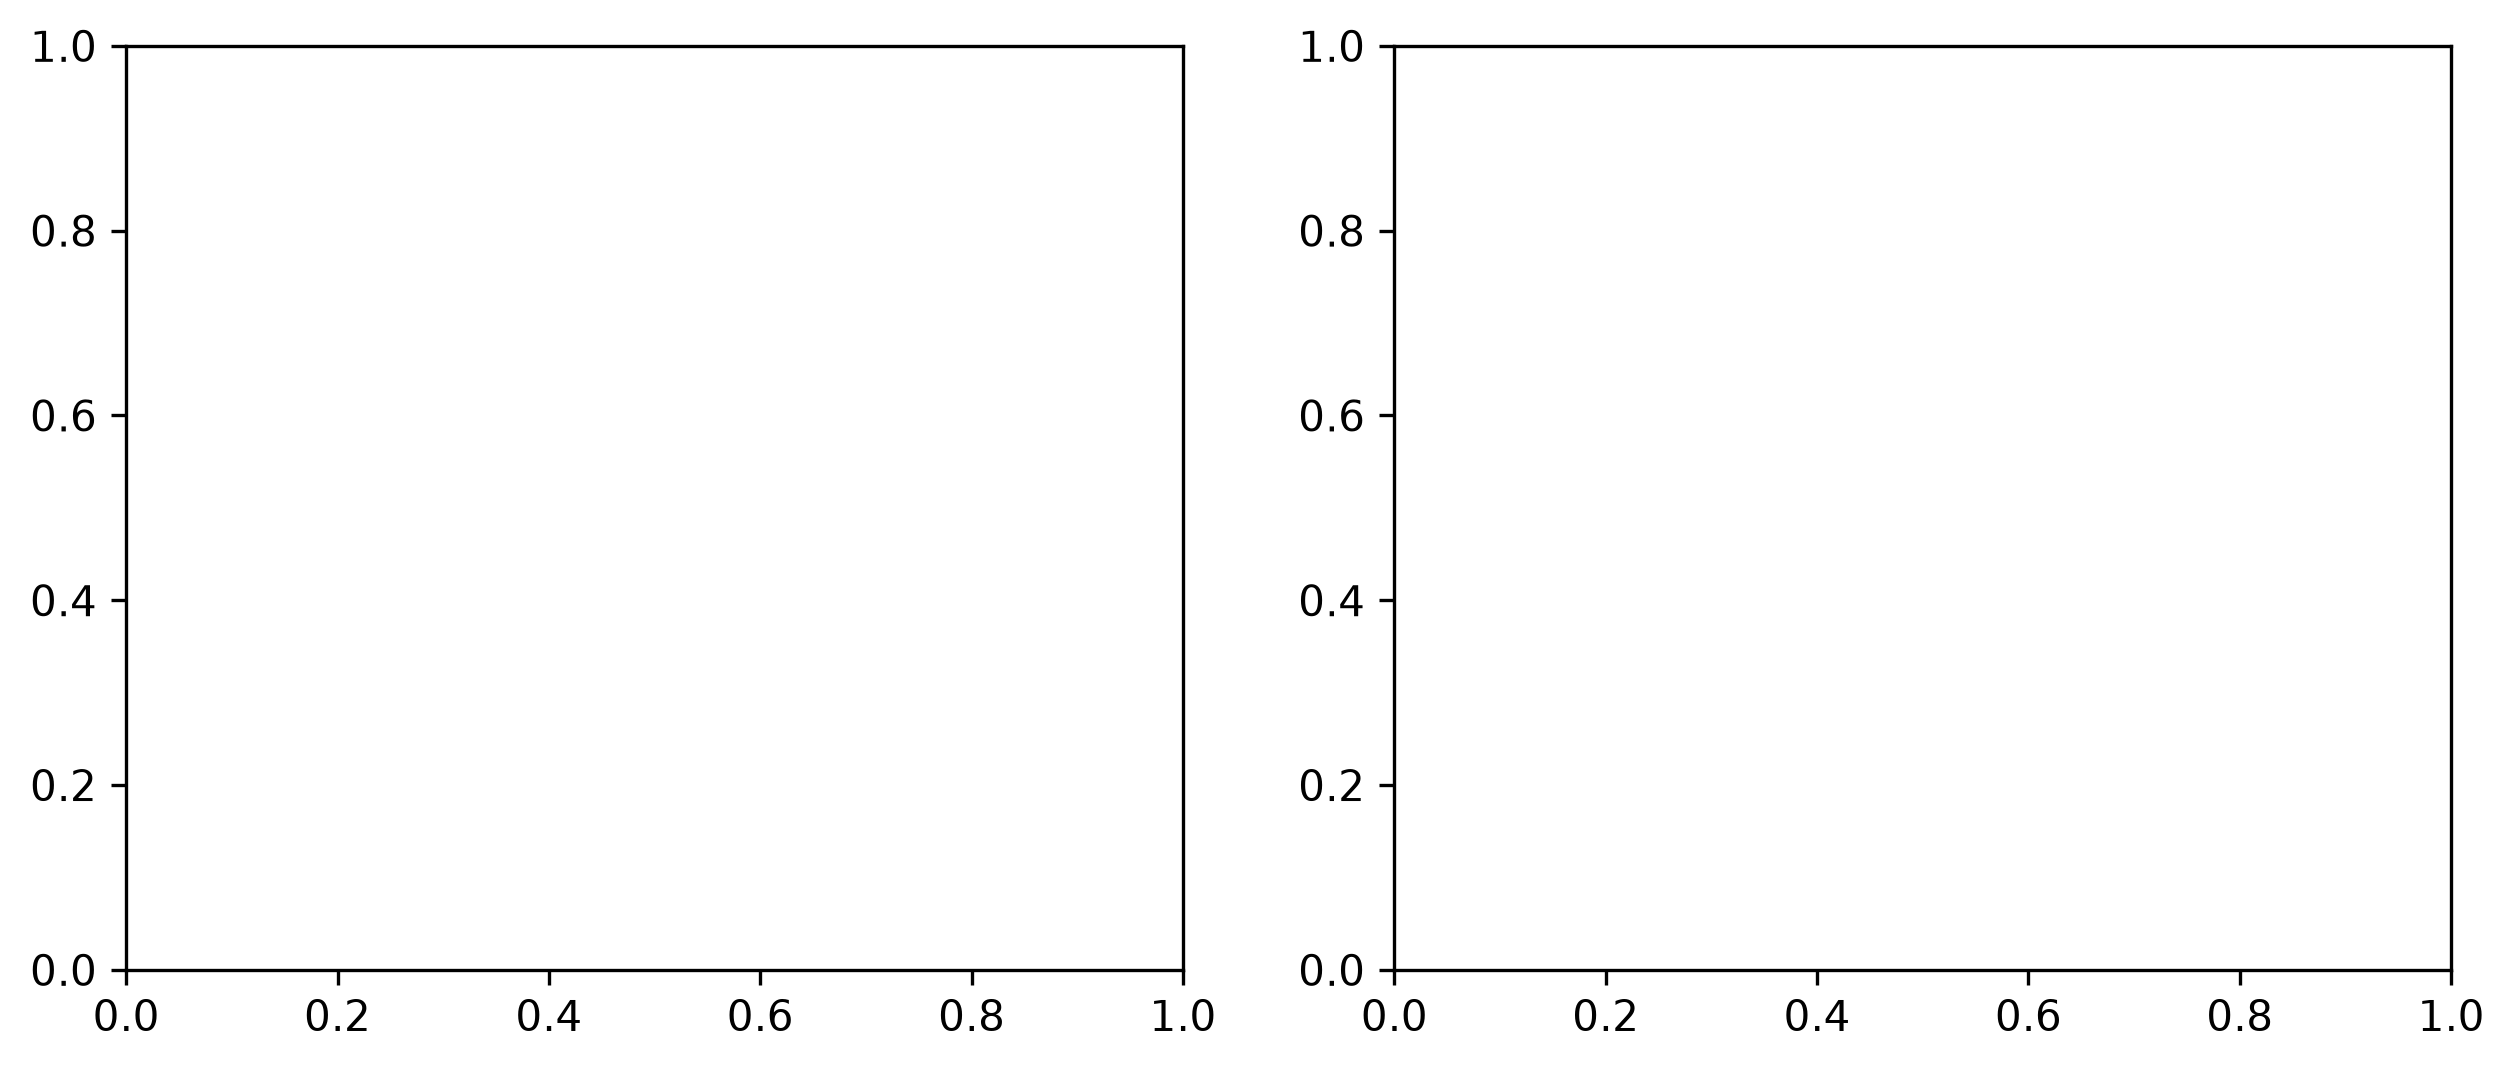

In [46]:
# @title Figure 13: Skeleton filtering and distance calculation

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

with cell.skeleton.mask_context(cell.skeleton.features['compartment'] != 2) as dendrite_cell:
    for i in range(2):
        ossify.plot.plot_morphology_2d(dendrite_cell,
                                       projection="xy",
                                       color="compartment",
                                       palette={ossify.SWC_SOMA: 'navy', ossify.SWC_AXON: 'dimgrey', ossify.SWC_DENDRITE: 'black'},  # SWC compartment codes (soma/axon/dendrite)
                                       linewidth="radius",            # line thickness follows neurite radius
                                       linewidth_norm=(100, 1000),    # radii (nm) mapped to the widths below
                                       widths=(0.25, 2),
                                       ax=ax[i])

    dendrite_syn_ids= dendrite_cell.annotations.post_syn.nodes.index.to_numpy()



# Input synapses
sns.scatterplot(data=post_syn_df.loc[post_syn_df.index.isin(dendrite_syn_ids)],
                x="ctr_pt_position_x", y="ctr_pt_position_y",
                s=3, hue='distance_to_root', palette= 'coolwarm',
                ax=ax[1], edgecolor=None, zorder=100)


ax[0].set(title="Dendrite Only (masked)", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
ax[1].set(title="Distance to soma", xlabel='X, medial-lateral (nm)', ylabel='Y, depth (nm)')
sns.despine()
sns.move_legend(ax[1], "upper left", bbox_to_anchor=(1, 1))
plt.show()